# 02 — Análisis Avanzado de Estacionalidad y Dinámicas Temporales

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | Departamentos y Distritos de Colombia

---

### ¿Por qué un notebook dedicado a la estacionalidad?

El notebook 01 (EDA) reveló un patrón estacional claro con picos en enero y julio.
Sin embargo, para construir modelos predictivos confiables necesitamos ir más allá
de la detección visual y responder preguntas críticas:

- **¿Cuál es el rezago exacto** entre el consumo de bienes gravados y el recaudo?
  (i.e., ¿el recaudo de enero refleja el consumo de diciembre o de enero?)
- **¿La estacionalidad es estable** o evoluciona con el tiempo?
- **¿Las verticales de negocio** (licores, cigarrillos, juegos de azar) tienen
  dinámicas estacionales distintas?
- **¿La migración del ERP en 2025** introdujo quiebres artificiales?
- **¿Qué parámetros de diferenciación** ($d$, $D$) requiere SARIMAX?

## Arquitectura Analítica

| Fase | Técnica | Objetivo | Output principal |
|------|---------|----------|------------------|
| **I** | Correlación Cruzada (CCF) | Validar el rezago óptimo entre consumo y recaudo | Lag óptimo (Dic→Ene, Jun→Jul) |
| **II** | Descomposición STL Avanzada | Aislar el perfil estacional fiscal | $F_s$ (fuerza estacional), decisión log1p |
| **III** | Dinámicas por Vertical | Deflactar y analizar elasticidades | Crecimiento orgánico vs inflacionario |
| **IV** | Anomalías y Change Points | Detectar quiebres (migración ERP 2025) | Dummies para SARIMAX |
| **V** | Validación de Estacionariedad | ADF + KPSS en 4 variantes | Parámetros $d$, $D$ para SARIMAX |

> **Dependencia**: Requiere `serie_mensual.csv` generado por `01_EDA_Completo.ipynb`.

In [1]:
import pandas as pd
import numpy as np

%run 00_config.py

# ── Paquetes estadísticos ──
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

# ── Cargar serie mensual agregada (generada en 01_EDA) ──
df_mensual = pd.read_csv(
    DATA_PROCESSED / 'serie_mensual.csv',
    parse_dates=['Fecha'], index_col='Fecha'
)
df_mensual.index.freq = 'MS'
serie = df_mensual['Recaudo_Total']

# ── Cargar dataset original para análisis por vertical ──
df_raw = pd.read_excel(DATA_FILE)
df_raw[COL_FECHA] = pd.to_datetime(df_raw[COL_FECHA])
df_raw[COL_VALOR] = pd.to_numeric(df_raw[COL_VALOR], errors='coerce')

n_meses = len(serie)
print(f"✅ Datos cargados — {n_meses} observaciones mensuales "
      f"({serie.index.min():%Y-%m} → {serie.index.max():%Y-%m})")
print(f"   Dataset vertical: {len(df_raw):,} registros × {df_raw.shape[1]} columnas")
print(f"   Categorías NombreSubGrupoFuente: {df_raw['NombreSubGrupoFuente'].nunique()}")
cats = df_raw['NombreSubGrupoFuente'].unique()
for c in sorted(cats):
    n = (df_raw['NombreSubGrupoFuente'] == c).sum()
    print(f"     • {c}  ({n:,} registros)")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


✅ Datos cargados — 51 observaciones mensuales (2021-10 → 2025-12)
   Dataset vertical: 149,648 registros × 13 columnas
   Categorías NombreSubGrupoFuente: 10
     • Ad Valorem Impuesto Consumo Cigarrillo y Tabacos  (1,817 registros)
     • Ajuste Contable - Presupuestal  (2 registros)
     • COLJUEGOS para Régimen Subsidiado  (77,781 registros)
     • Componente Especifico Consumo Cigarrillos y Tabacos  (1,221 registros)
     • Cotizaciones Régimen Contributivo  (17 registros)
     • Impoconsumo Cervezas y Sifones  (3,862 registros)
     • Impoconsumo Licores, Vinos, Aperitivos y Similares  (7,850 registros)
     • Monopolio de Juegos de Suerte y Azar Entidades Territoriales  (29,722 registros)
     • Otros Recursos Propios Destinados al Aseguramiento  (1,330 registros)
     • Rendimientos Sobre Recursos Entregados en Administración  (26,046 registros)


---

## Fase I — Refinamiento de la «Verdad Temporal» (Lag Analysis)

### Hipótesis Central

> *El recaudo de enero refleja el consumo masivo de diciembre; el de julio,
> el gasto de vacaciones y primas de junio.*

Esta hipótesis se basa en el **ciclo presupuestal colombiano**: los impuestos
al consumo (licores, cerveza, cigarrillos) se causan en el mes de la venta pero
se transfieren a ADRES con 1-2 meses de rezago contable. Así, el consumo
masivo de diciembre (fiestas navideñas, primas) se materializa como recaudo en enero.

### ¿Qué es la Correlación Cruzada (CCF)?

La **CCF** (Cross-Correlation Function) mide la correlación entre dos series
temporales a diferentes rezagos (lags). Si $X_t$ es el consumo y $Y_t$ el
recaudo, la CCF en lag $k$ es:

$$\text{CCF}(k) = \text{Corr}(X_{t-k},\; Y_t)$$

- **Lag negativo ($k < 0$):** $X$ *lidera* $Y$ (el consumo anticipa el recaudo).
- **Lag positivo ($k > 0$):** $Y$ *lidera* $X$ (el recaudo anticipa el consumo).
- **Lag 0:** Relación contemporánea.

La banda de confianza al 95% (intervalo de Bartlett: $\pm 1.96/\sqrt{n}$)
identifica correlaciones estadísticamente significativas.

Para validar la hipótesis se emplean dos técnicas:
1. **CCF entre recaudo y consumo/IPC**, identificando el lag óptimo.
2. **Heatmap de autocorrelación por mes**, que revela si Ene y Jul dependen
   del mes inmediatamente anterior.

  📊 Figura guardada: 02_ccf_consumo_ipc.png


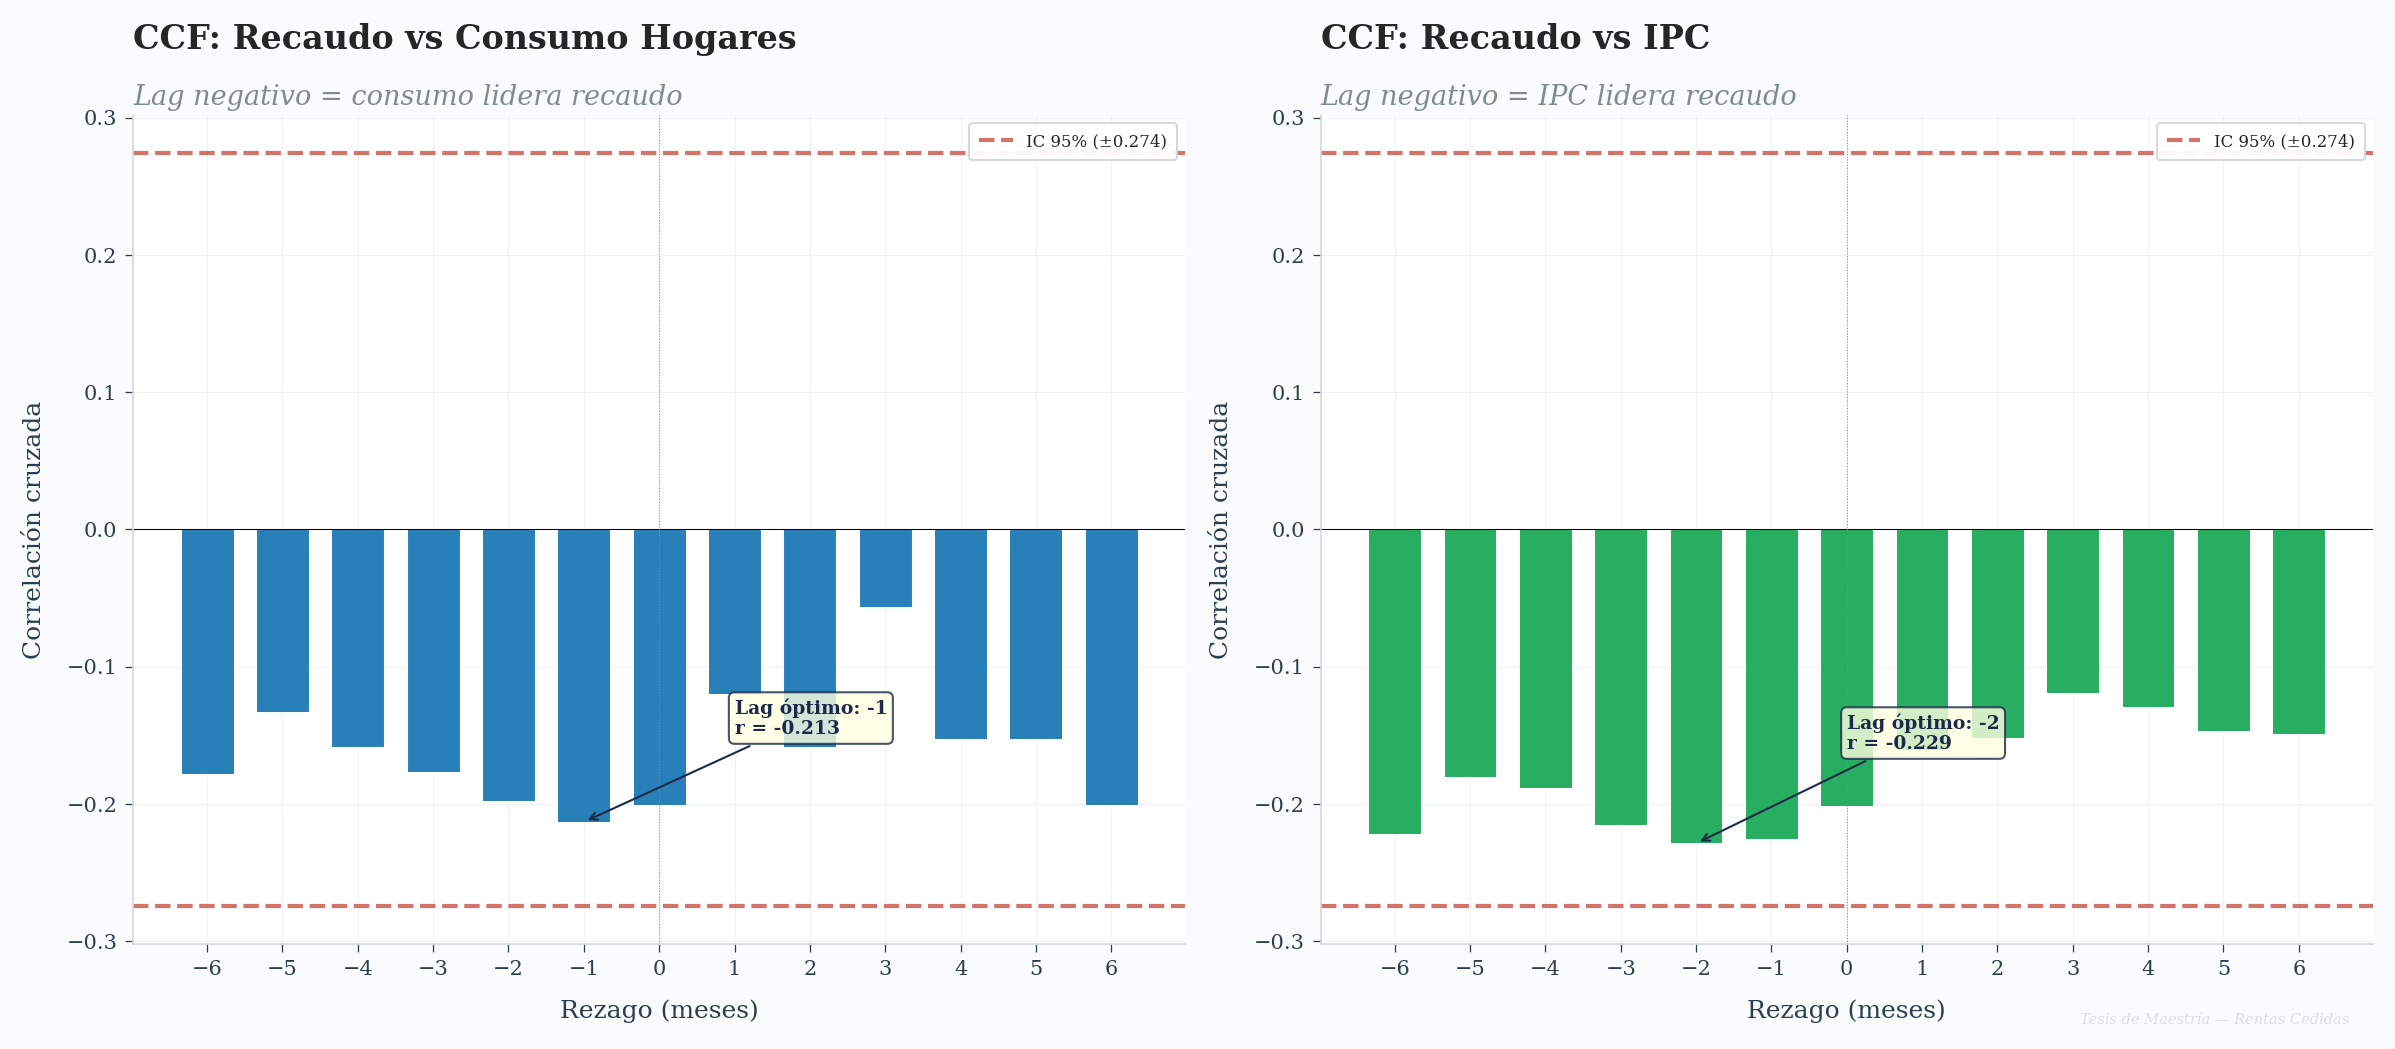


══════════════════════════════════════════════════════════════════════
RESULTADOS CCF — REZAGO ÓPTIMO
══════════════════════════════════════════════════════════════════════
  Consumo Hogares → Recaudo:  Lag = -1  (r = -0.2132)
  IPC → Recaudo:              Lag = -2  (r = -0.2288)
  IC 95% (Bartlett):          ±0.2745

  → El consumo ANTICIPA el recaudo por 1 mes(es)


In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I.1 — Correlación Cruzada (CCF) con Variables de Consumo
# ══════════════════════════════════════════════════════════════

# ── Construir serie proxy de consumo mensualizada ──
macro_df = pd.DataFrame(MACRO_DATA).T
macro_df.index.name = 'Año'

fechas_mensuales = serie.index
macro_mensual = pd.DataFrame(index=fechas_mensuales)

for col in ['IPC', 'Consumo_Hogares', 'Salario_Minimo']:
    serie_proxy = pd.Series(dtype=float, index=fechas_mensuales)
    for año, val in macro_df[col].items():
        mask = fechas_mensuales.year == año
        serie_proxy[mask] = val
    macro_mensual[col] = serie_proxy.astype(float).interpolate(method='linear')

# ── Normalizar (z-score) ──
recaudo_norm = (serie - serie.mean()) / serie.std()
consumo_norm = ((macro_mensual['Consumo_Hogares']
                 - macro_mensual['Consumo_Hogares'].mean())
                / macro_mensual['Consumo_Hogares'].std())
ipc_norm = ((macro_mensual['IPC'] - macro_mensual['IPC'].mean())
            / macro_mensual['IPC'].std())

# ── Función de Correlación Cruzada manual ──
max_lag = 6

def ccf_manual(x, y, max_lag):
    n = len(x)
    vals = []
    for lag in range(-max_lag, max_lag + 1):
        if lag >= 0:
            corr = np.corrcoef(x[lag:], y[:n-lag])[0, 1] if n - lag > 2 else 0
        else:
            corr = np.corrcoef(x[:n+lag], y[-lag:])[0, 1] if n + lag > 2 else 0
        vals.append(corr)
    return vals

lags = list(range(-max_lag, max_lag + 1))
ccf_consumo = ccf_manual(recaudo_norm.values, consumo_norm.values, max_lag)
ccf_ipc     = ccf_manual(recaudo_norm.values, ipc_norm.values, max_lag)

ci_95 = 1.96 / np.sqrt(len(serie))    # Bartlett

# ── Gráfica CCF dual ──
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_DUAL)

for ax, ccf_vals, titulo, color_base, subtitulo in [
    (axes[0], ccf_consumo, 'CCF: Recaudo vs Consumo Hogares',
     C_TERTIARY, 'Lag negativo = consumo lidera recaudo'),
    (axes[1], ccf_ipc, 'CCF: Recaudo vs IPC',
     C_QUATERNARY, 'Lag negativo = IPC lidera recaudo'),
]:
    colores_bar = [C_SECONDARY if abs(v) > ci_95 else color_base for v in ccf_vals]
    ax.bar(lags, ccf_vals, color=colores_bar, edgecolor='white',
           linewidth=0.5, width=0.7)
    ax.axhline(y= ci_95, color=C_SECONDARY, ls='--', alpha=0.7,
               label=f'IC 95% (±{ci_95:.3f})')
    ax.axhline(y=-ci_95, color=C_SECONDARY, ls='--', alpha=0.7)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axvline(x=0, color=C_TEXT_LIGHT, lw=0.5, ls=':')
    ax.set_xlabel('Rezago (meses)', fontdict=FONT_AXIS)
    ax.set_ylabel('Correlación cruzada', fontdict=FONT_AXIS)
    ax.set_xticks(lags)
    ax.legend(fontsize=8)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, titulo, subtitulo)

    # Anotar lag óptimo
    idx_opt = int(np.argmax(np.abs(ccf_vals)))
    lag_opt = lags[idx_opt]
    val_opt = ccf_vals[idx_opt]
    ax.annotate(
        f'Lag óptimo: {lag_opt}\nr = {val_opt:.3f}',
        xy=(lag_opt, val_opt),
        xytext=(lag_opt + 2, val_opt * 0.7),
        arrowprops=dict(arrowstyle='->', color=C_PRIMARY),
        fontsize=9, fontweight='bold', color=C_PRIMARY,
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='lightyellow', edgecolor=C_PRIMARY, alpha=0.8))

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_ccf_consumo_ipc', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
idx_c = int(np.argmax(np.abs(ccf_consumo)))
idx_i = int(np.argmax(np.abs(ccf_ipc)))
lag_c, val_c = lags[idx_c], ccf_consumo[idx_c]
lag_i, val_i = lags[idx_i], ccf_ipc[idx_i]
print(f"\n{'═'*70}")
print(f"RESULTADOS CCF — REZAGO ÓPTIMO")
print(f"{'═'*70}")
print(f"  Consumo Hogares → Recaudo:  Lag = {lag_c:+d}  (r = {val_c:.4f})")
print(f"  IPC → Recaudo:              Lag = {lag_i:+d}  (r = {val_i:.4f})")
print(f"  IC 95% (Bartlett):          ±{ci_95:.4f}")
print()
if lag_c < 0:
    print(f"  → El consumo ANTICIPA el recaudo por {abs(lag_c)} mes(es)")
elif lag_c > 0:
    print(f"  → El recaudo SIGUE al consumo con {lag_c} mes(es) de rezago")
else:
    print(f"  → Recaudo y consumo son contemporáneos (lag = 0)")

  📊 Figura guardada: 02_heatmap_lag_mensual.png


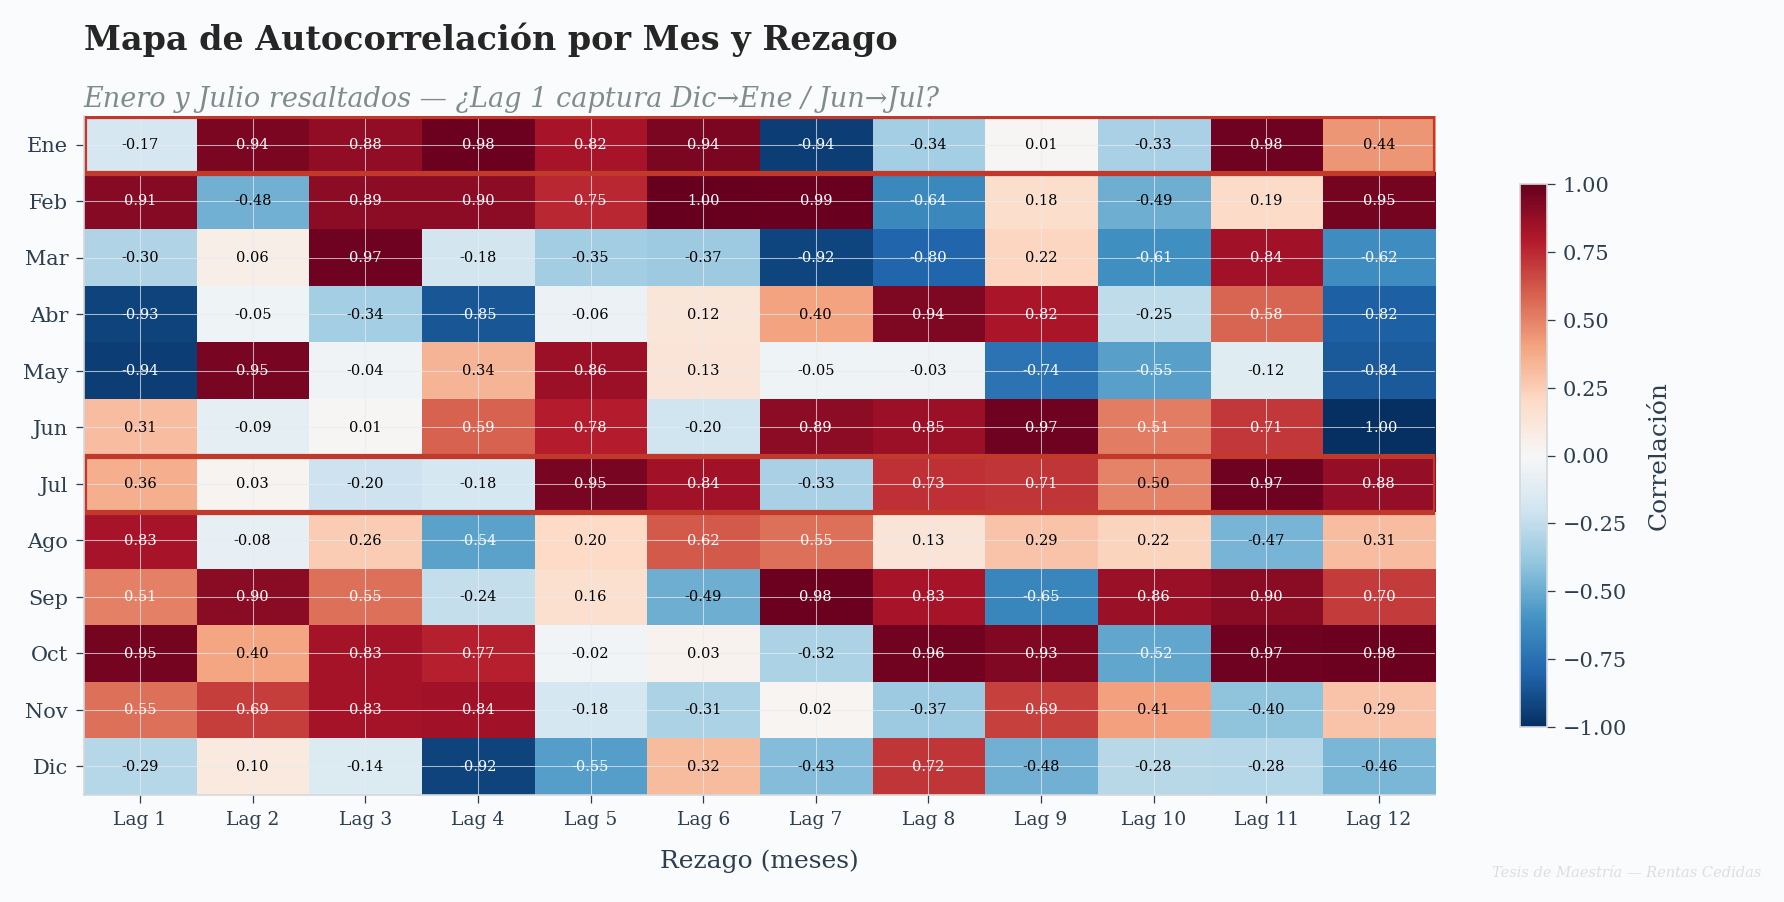


══════════════════════════════════════════════════════════════════════
ESTRUCTURA DE REZAGO — MESES PICO
══════════════════════════════════════════════════════════════════════

  ENERO:
    Lag 1: r = -0.1658  (✗ No significativo)
    Lag 2: r = 0.9441  (✓ Significativo)
    Lag 3: r = 0.8837  (✓ Significativo)
    → Lag óptimo: 4  (r = 0.9811)

  JULIO:
    Lag 1: r = 0.3605  (✓ Significativo)
    Lag 2: r = 0.0255  (✗ No significativo)
    Lag 3: r = -0.2034  (✗ No significativo)
    → Lag óptimo: 11  (r = 0.9688)

──────────────────────────────────────────────────────────────────────
VALIDACIÓN DE HIPÓTESIS
  Correlación Enero ↔ Diciembre (lag 1):  r = -0.1658
  Correlación Julio ↔ Junio    (lag 1):   r = 0.3605
  ⚠️ NO CONCLUYENTE: relación lag-1 débil; 
     el efecto puede ser lag-12 (estacionalidad pura)


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE I.2 — Heatmap de Autocorrelación por Mes y Rezago
# ══════════════════════════════════════════════════════════════

n_lags = 12
acf_by_month = np.zeros((12, n_lags))

for mes in range(1, 13):
    mask = serie.index.month == mes
    for lag in range(1, n_lags + 1):
        shifted = serie.shift(lag)
        valid   = ~shifted.isna()
        sub_o = serie[valid & mask]
        sub_l = shifted[valid & mask]
        if len(sub_o) > 2:
            acf_by_month[mes-1, lag-1] = np.corrcoef(
                sub_o.values, sub_l.values)[0, 1]

# ── Heatmap ──
fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD)
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun',
                'Jul','Ago','Sep','Oct','Nov','Dic']

im = ax.imshow(acf_by_month, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(n_lags))
ax.set_xticklabels([f'Lag {i+1}' for i in range(n_lags)], fontsize=9)
ax.set_yticks(range(12))
ax.set_yticklabels(meses_labels, fontsize=10)
ax.set_xlabel('Rezago (meses)', fontdict=FONT_AXIS)

# Anotar valores
for i in range(12):
    for j in range(n_lags):
        v = acf_by_month[i, j]
        color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7, color=color)

# Resaltar Enero y Julio
for mes_pico in [0, 6]:
    rect = plt.Rectangle((-0.5, mes_pico - 0.5), n_lags, 1,
                          lw=2.5, edgecolor=C_SECONDARY, facecolor='none')
    ax.add_patch(rect)

plt.colorbar(im, ax=ax, label='Correlación', shrink=0.8)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Mapa de Autocorrelación por Mes y Rezago',
                       'Enero y Julio resaltados — ¿Lag 1 captura Dic→Ene / Jun→Jul?')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_heatmap_lag_mensual', OUTPUTS_FIGURES)
plt.show()

# ── Análisis enfocado ──
ci = ci_95
print(f"\n{'═'*70}")
print(f"ESTRUCTURA DE REZAGO — MESES PICO")
print(f"{'═'*70}")
for m, nombre in [(1, 'ENERO'), (7, 'JULIO')]:
    print(f"\n  {nombre}:")
    for lag in range(1, 4):
        v = acf_by_month[m-1, lag-1]
        sig = '✓ Significativo' if abs(v) > ci else '✗ No significativo'
        print(f"    Lag {lag}: r = {v:.4f}  ({sig})")
    best = int(np.argmax(np.abs(acf_by_month[m-1, :]))) + 1
    print(f"    → Lag óptimo: {best}  (r = {acf_by_month[m-1, best-1]:.4f})")

lag1_ene = acf_by_month[0, 0]
lag1_jul = acf_by_month[6, 0]
print(f"\n{'─'*70}")
print(f"VALIDACIÓN DE HIPÓTESIS")
print(f"  Correlación Enero ↔ Diciembre (lag 1):  r = {lag1_ene:.4f}")
print(f"  Correlación Julio ↔ Junio    (lag 1):   r = {lag1_jul:.4f}")
if lag1_ene > 0.3:
    print(f"  ✅ CONFIRMADA: Ene depende del mes anterior (r > 0.3)")
else:
    print(f"  ⚠️ NO CONCLUYENTE: relación lag-1 débil; ")
    print(f"     el efecto puede ser lag-12 (estacionalidad pura)")

---

## Fase II — Descomposición Estacional Avanzada (STL)

### ¿Por qué STL en lugar de la descomposición clásica?

En el notebook 01 usamos la descomposición clásica (`seasonal_decompose`), que
asume que la estacionalidad es **idéntica todos los años**. Esto es una
simplificación fuerte: en la realidad, la estacionalidad puede evolucionar
(e.g., cambios regulatorios, nuevos impuestos).

**STL** (Seasonal-Trend decomposition using Loess), propuesto por Cleveland
et al. (1990), supera esta limitación:

$$Y_t = T_t + S_t + R_t$$

| Componente | Descripción | Método |
|------------|-------------|--------|
| $T_t$ | Tendencia | Suavizado Loess (locally weighted regression) |
| $S_t$ | Estacionalidad | Iteración períodica con pesos robustos |
| $R_t$ | Residuo | Componente irregular |

**Ventajas sobre `decompose` clásica:**
1. **Robusta frente a outliers:** Usa weighted least squares que reduce la
   influencia de observaciones atípicas.
2. **Estacionalidad variable:** Permite que $S_t$ cambie suavemente con el tiempo.
3. **Control granular:** Parámetros `seasonal` y `trend` permiten ajustar
   la suavidad de cada componente.

### Heterocedasticidad estacional

Se evalúa si la **varianza de la estacionalidad aumenta con el nivel** de la
serie. Si la correlación nivel-varianza es fuerte ($r > 0.5$), la transformación
`log1p` es necesaria para estabilizar la varianza antes del modelado.

> **¿Qué es `log1p`?** Es $\log(1 + x)$, una variante de la transformación
> logarítmica que maneja valores cero o cercanos a cero sin producir $-\infty$.
> Es la transformación estándar para series monetarias con heterocedasticidad.

  📊 Figura guardada: 02_stl_descomposicion.png


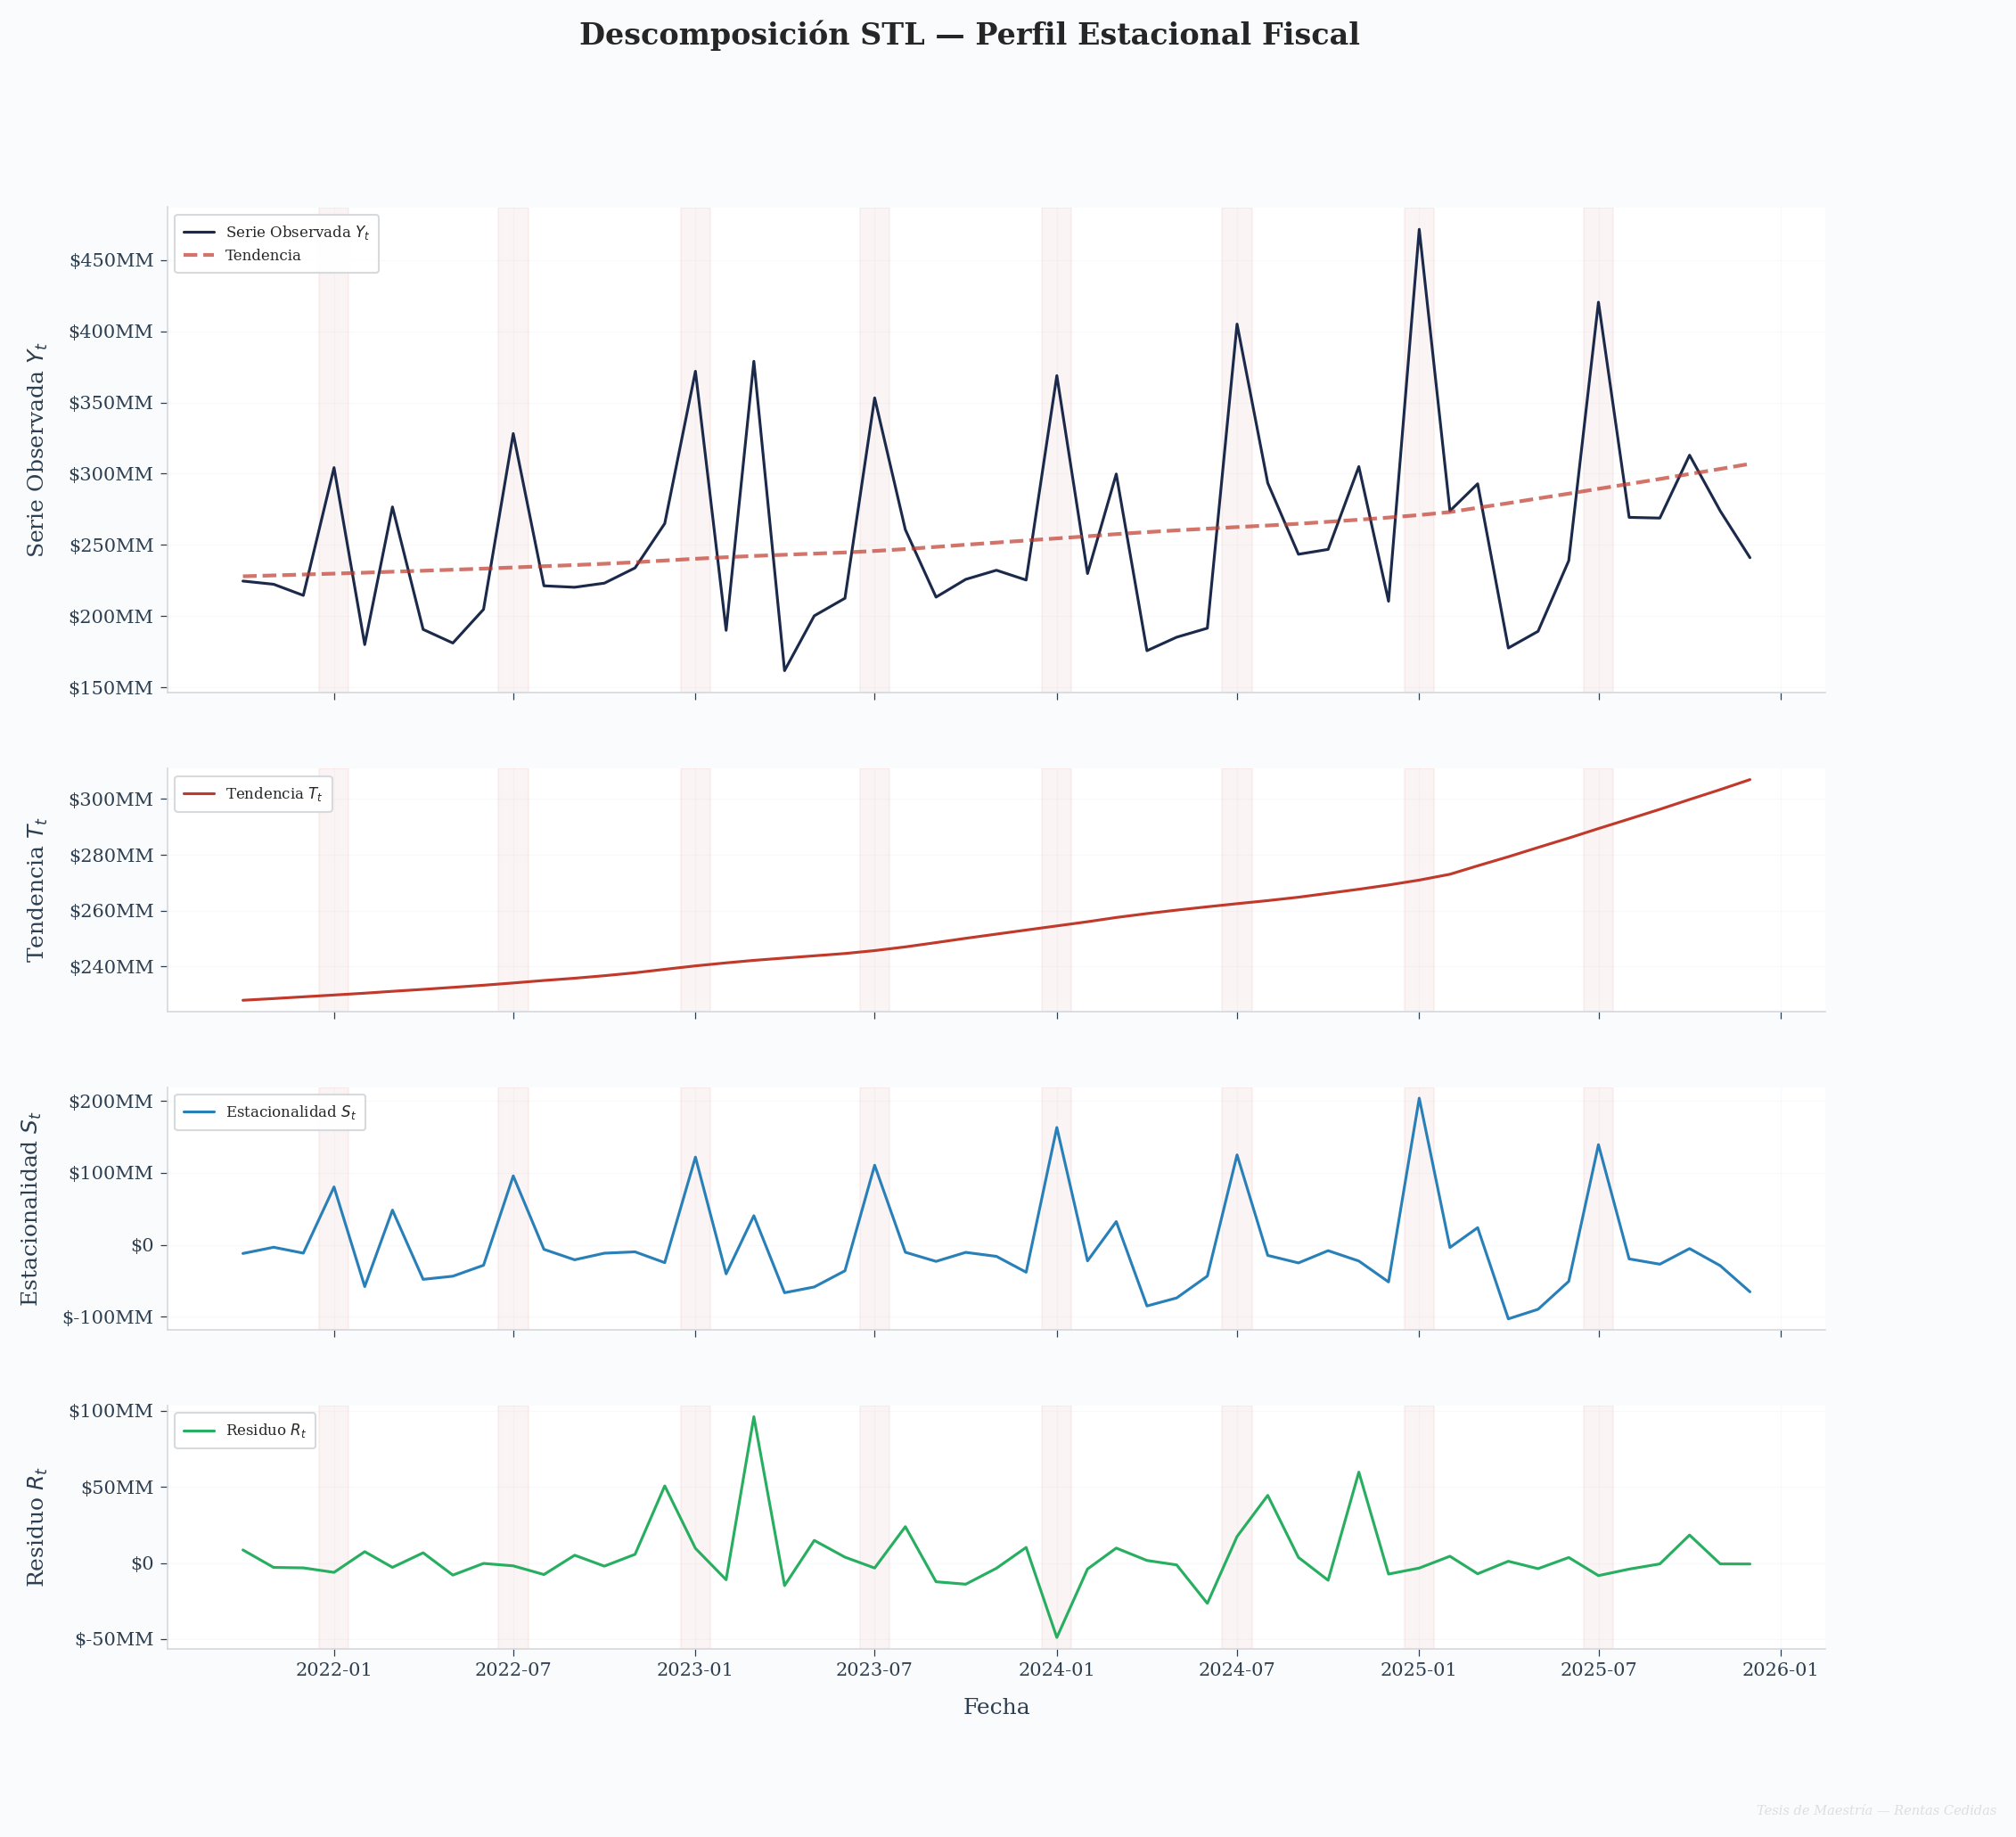


══════════════════════════════════════════════════════════════════════
MÉTRICAS DE ROBUSTEZ (Hyndman & Athanasopoulos)
══════════════════════════════════════════════════════════════════════
  Fuerza estacional (F_s):  0.9016  ← FUERTE
  Fuerza tendencia  (F_t):  0.4892  ← DÉBIL
  Var residuo / Var total:  0.0944
  Amplitud estacional σ_S:  $66,502,741,479
  Amplitud residual   σ_R:  $21,472,639,867


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE II.1 — Descomposición STL: Perfil Estacional Fiscal
# ══════════════════════════════════════════════════════════════

stl = STL(serie, period=12, seasonal=13, robust=True)
res_stl = stl.fit()

# ── Gráfica profesional ──
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(4, 1, hspace=0.25, height_ratios=[2, 1, 1, 1])

componentes = [
    ('Serie Observada $Y_t$',   serie,            C_PRIMARY,    True),
    ('Tendencia $T_t$',         res_stl.trend,    C_SECONDARY,  False),
    ('Estacionalidad $S_t$',    res_stl.seasonal, C_TERTIARY,   False),
    ('Residuo $R_t$',           res_stl.resid,    C_QUATERNARY, False),
]

for i, (titulo, datos, color, show_trend) in enumerate(componentes):
    ax = fig.add_subplot(gs[i])
    ax.plot(datos.index, datos.values, color=color, lw=1.5, label=titulo)
    if show_trend:
        ax.plot(res_stl.trend.index, res_stl.trend.values,
                color=C_SECONDARY, lw=2, ls='--', alpha=0.7, label='Tendencia')
    ax.set_ylabel(titulo, fontdict=FONT_AXIS)
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        formato_pesos_eje(ax, eje='y')
    ax.legend(loc='upper left', fontsize=8)
    if i < 3:
        ax.set_xticklabels([])
    # Sombrear meses pico
    for fecha in datos.index:
        if fecha.month in MESES_PICO:
            ax.axvspan(fecha - pd.Timedelta(days=15),
                       fecha + pd.Timedelta(days=15),
                       alpha=0.05, color=C_SECONDARY)

ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
fig.suptitle('Descomposición STL — Perfil Estacional Fiscal',
             fontsize=16, fontweight='bold', y=0.98, fontfamily='serif')
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_stl_descomposicion', OUTPUTS_FIGURES)
plt.show()

# ── Métricas de robustez (Hyndman) ──
F_seasonal = max(0, 1 - res_stl.resid.var()
                 / (res_stl.seasonal + res_stl.resid).var())
F_trend    = max(0, 1 - res_stl.resid.var()
                 / (res_stl.trend + res_stl.resid).var())

print(f"\n{'═'*70}")
print(f"MÉTRICAS DE ROBUSTEZ (Hyndman & Athanasopoulos)")
print(f"{'═'*70}")
print(f"  Fuerza estacional (F_s):  {F_seasonal:.4f}  "
      f"{'← FUERTE' if F_seasonal > 0.64 else '← DÉBIL'}")
print(f"  Fuerza tendencia  (F_t):  {F_trend:.4f}  "
      f"{'← FUERTE' if F_trend > 0.64 else '← DÉBIL'}")
print(f"  Var residuo / Var total:  {res_stl.resid.var() / serie.var():.4f}")
print(f"  Amplitud estacional σ_S:  ${res_stl.seasonal.std():,.0f}")
print(f"  Amplitud residual   σ_R:  ${res_stl.resid.std():,.0f}")

  📊 Figura guardada: 02_heterocedasticidad_log1p.png


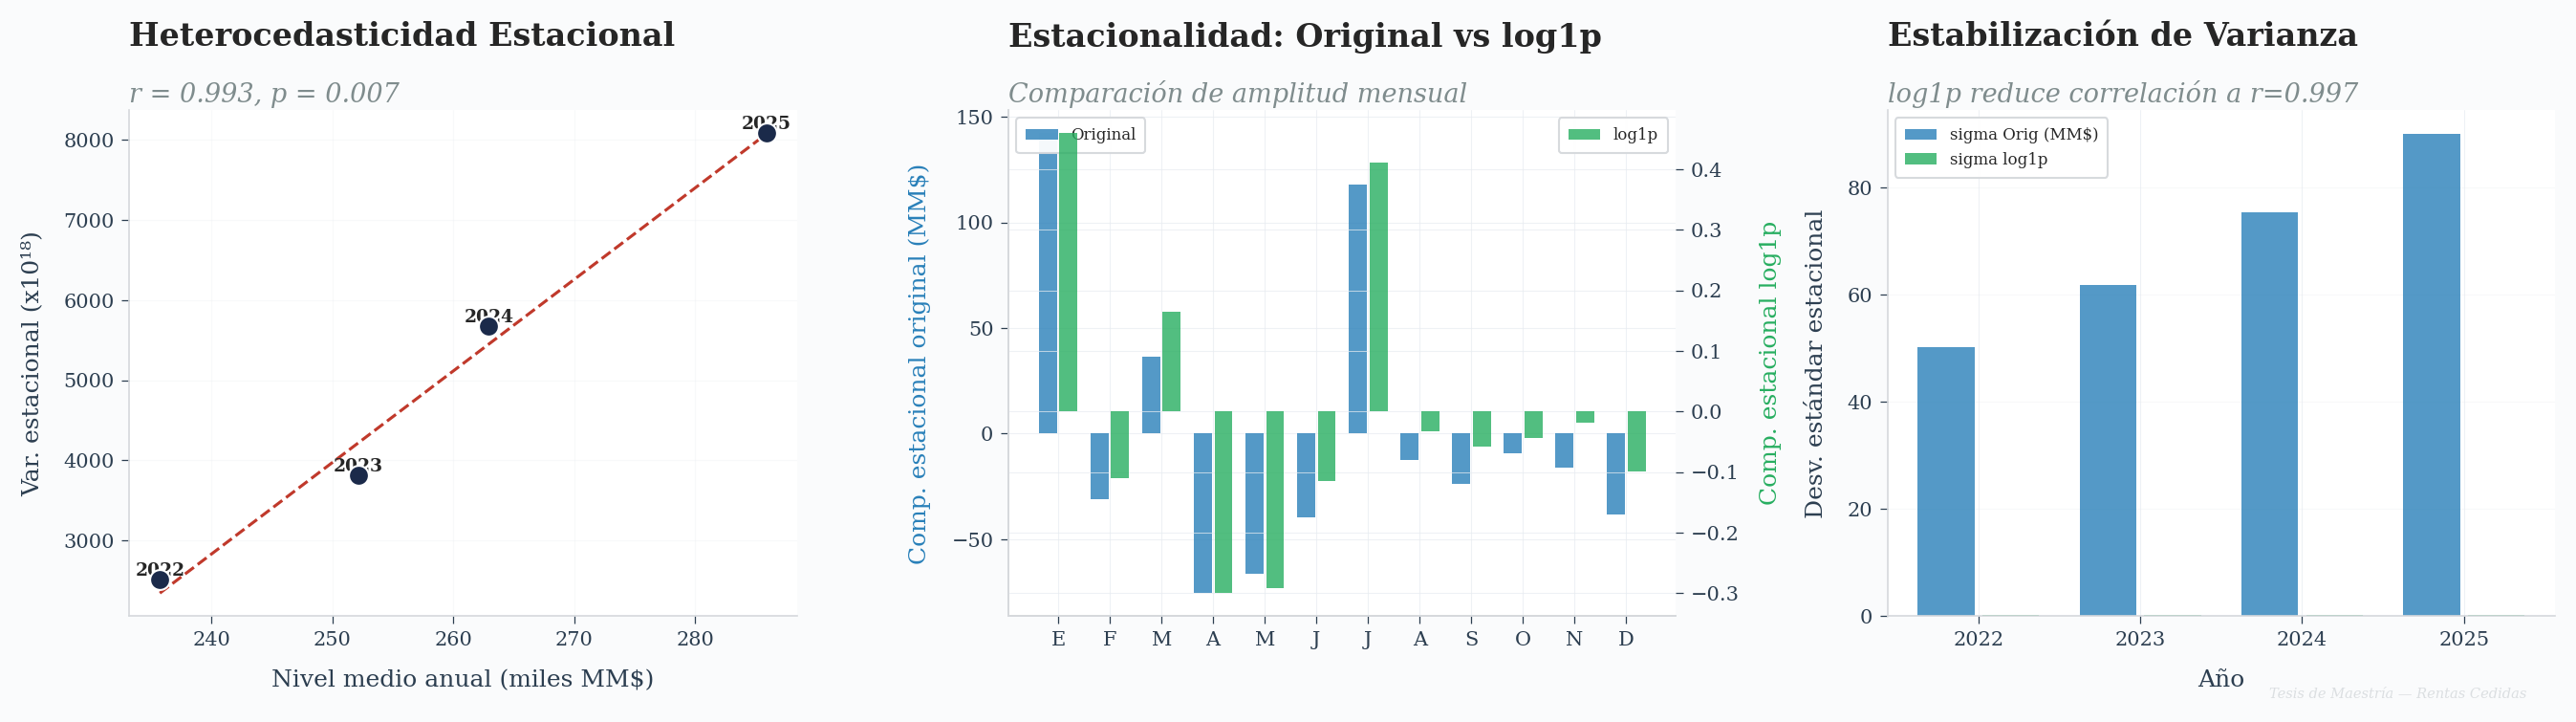


══════════════════════════════════════════════════════════════════════
DIAGNÓSTICO DE HETEROCEDASTICIDAD ESTACIONAL
══════════════════════════════════════════════════════════════════════
  Corr nivel-varianza (original): r = 0.9931  (p = 0.0069)
  Corr nivel-varianza (log1p):    r = 0.9971  (p = 0.0029)
  F_s original:   0.9016
  F_s log1p:      0.8956

  ✅ APLICAR log1p — varianza creciente detectada
     Modelar con serie log-transformada para SARIMA/SARIMAX


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE II.2 — Diagnóstico de Heterocedasticidad + Transformación log1p
# ══════════════════════════════════════════════════════════════

# ── Nivel vs Varianza estacional por año ──
anos = sorted(serie.index.year.unique())
nivel_medio, var_est = [], []
for y in anos:
    m = serie.index.year == y
    if m.sum() >= 6:
        nivel_medio.append(serie[m].mean())
        var_est.append(res_stl.seasonal[m].var())
nivel_medio = np.array(nivel_medio)
var_est     = np.array(var_est)
corr_nv, p_nv = stats.pearsonr(nivel_medio, var_est)

# ── STL sobre serie log-transformada ──
serie_log = np.log1p(serie.clip(lower=0))
stl_log   = STL(serie_log, period=12, seasonal=13, robust=True)
res_log   = stl_log.fit()
F_s_log   = max(0, 1 - res_log.resid.var()
                / (res_log.seasonal + res_log.resid).var())

var_est_log, nivel_log = [], []
for y in anos:
    m = serie_log.index.year == y
    if m.sum() >= 6:
        nivel_log.append(serie_log[m].mean())
        var_est_log.append(res_log.seasonal[m].var())
corr_log, p_log = stats.pearsonr(nivel_log, var_est_log)

# ── Gráfica comparativa (3 paneles) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Nivel vs Varianza (scatter)
ax = axes[0]
ax.scatter(nivel_medio/1e9, var_est/1e18, color=C_PRIMARY, s=100,
           zorder=5, edgecolors='white')
valid_anos = [y for y in anos if serie[serie.index.year == y].count() >= 6]
for i, year in enumerate(valid_anos):
    ax.annotate(str(year), (nivel_medio[i]/1e9, var_est[i]/1e18),
                fontsize=9, ha='center', va='bottom', fontweight='bold')
z = np.polyfit(nivel_medio/1e9, var_est/1e18, 1)
x_l = np.linspace(nivel_medio.min()/1e9, nivel_medio.max()/1e9, 50)
ax.plot(x_l, np.polyval(z, x_l), '--', color=C_SECONDARY, lw=1.5)
ax.set_xlabel('Nivel medio anual (miles MM$)', fontdict=FONT_AXIS)
ax.set_ylabel('Var. estacional (x10¹⁸)', fontdict=FONT_AXIS)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Heterocedasticidad Estacional',
                       f'r = {corr_nv:.3f}, p = {p_nv:.3f}')

# Panel 2: Comp. estacional por mes (original vs log1p)
ax  = axes[1]
ax2 = ax.twinx()
meses = range(1, 13)
est_o = [res_stl.seasonal[serie.index.month == m].mean() for m in meses]
est_l = [res_log.seasonal[serie_log.index.month == m].mean() for m in meses]
ml = ['E','F','M','A','M','J','J','A','S','O','N','D']
ax.bar(np.arange(12) - 0.2, [e/1e9 for e in est_o], 0.35,
       color=C_TERTIARY, alpha=0.8, label='Original')
ax2.bar(np.arange(12) + 0.2, est_l, 0.35,
        color=C_QUATERNARY, alpha=0.8, label='log1p')
ax.set_xticks(range(12)); ax.set_xticklabels(ml)
ax.set_ylabel('Comp. estacional original (MM$)',
              fontdict=FONT_AXIS, color=C_TERTIARY)
ax2.set_ylabel('Comp. estacional log1p',
               fontdict=FONT_AXIS, color=C_QUATERNARY)
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Estacionalidad: Original vs log1p',
                       'Comparación de amplitud mensual')

# Panel 3: Desv. estándar por año
ax = axes[2]
x_pos = np.arange(len(valid_anos))
ax.bar(x_pos - 0.2, np.sqrt(var_est)/1e9, 0.35,
       color=C_TERTIARY, alpha=0.8, label='sigma Orig (MM$)')
ax.bar(x_pos + 0.2, np.sqrt(var_est_log), 0.35,
       color=C_QUATERNARY, alpha=0.8, label='sigma log1p')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(y) for y in valid_anos])
ax.set_xlabel('Año', fontdict=FONT_AXIS)
ax.set_ylabel('Desv. estándar estacional', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Estabilización de Varianza',
                       f'log1p reduce correlación a r={corr_log:.3f}')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_heterocedasticidad_log1p', OUTPUTS_FIGURES)
plt.show()

# ── Decisión ──
necesita_log = corr_nv > 0.5 and p_nv < 0.1
print(f"\n{'═'*70}")
print(f"DIAGNÓSTICO DE HETEROCEDASTICIDAD ESTACIONAL")
print(f"{'═'*70}")
print(f"  Corr nivel-varianza (original): r = {corr_nv:.4f}  (p = {p_nv:.4f})")
print(f"  Corr nivel-varianza (log1p):    r = {corr_log:.4f}  (p = {p_log:.4f})")
print(f"  F_s original:   {F_seasonal:.4f}")
print(f"  F_s log1p:      {F_s_log:.4f}")
print()
if necesita_log:
    print(f"  ✅ APLICAR log1p — varianza creciente detectada")
    print(f"     Modelar con serie log-transformada para SARIMA/SARIMAX")
else:
    print(f"  ⚠️ log1p OPCIONAL — heterocedasticidad no conclusiva")
    print(f"     Serie original es viable; log1p no mejora la estabilidad de forma significativa")

---

## Fase III — Modelación de Dinámicas por Vertical de Negocio

### ¿Por qué analizar por verticales?

La serie total de rentas cedidas agrega fuentes con dinámicas económicas
muy distintas. Analizar cada vertical por separado permite:
- **Identificar drivers específicos:** El consumo de licores responde a la
  inflación (efecto precio), mientras que los juegos de azar responden al ingreso.
- **Diagnosticar riesgos:** Si una fuente concentrada muestra decrecimiento real,
  genera riesgo para la sostenibilidad del recaudo total.
- **Informar la selección de regresores** para cada modelo posterior.

### 3.1 Licores y Cigarrillos — Crecimiento orgánico vs efecto precio

Se **deflacta** el recaudo nominal con el IPC para separar:
- **Crecimiento orgánico** (volumen real): ¿se consume más o menos en términos reales?
- **Efecto precio** (inflación): ¿el recaudo crece solo porque suben los precios
  de los productos gravados?

Esta distinción es fundamental porque un recaudo que solo crece por inflación
no representa un fortalecimiento real de la base fiscal.

### 3.2 Juegos de Azar y Apuestas — Elasticidad ingreso

Se cruza el recaudo con el **Salario Mínimo (SMLV)** y se estima la
**elasticidad ingreso** ($\beta$ de regresión log-log):

$$\log(\text{Recaudo}) = \alpha + \beta \cdot \log(\text{SMLV}) + \varepsilon$$

- $|\beta| < 1$: **Inelástico** — el gasto en azar es relativamente estable
  frente a cambios en el ingreso. Los hogares mantienen su gasto lúdico
  incluso en períodos de contracción.
- $|\beta| > 1$: **Elástico** — el gasto en azar responde fuertemente al ingreso,
  haciéndolo proclíclico y volátil.

Categorías identificadas como Licores/Cigarrillos/Cerveza:
  • Impoconsumo Cervezas y Sifones  (3,862 reg, $1170.0MM)
  • Impoconsumo Licores, Vinos, Aperitivos y Similares  (7,850 reg, $2141.0MM)
  • Componente Especifico Consumo Cigarrillos y Tabacos  (1,221 reg, $3196.4MM)
  • Ad Valorem Impuesto Consumo Cigarrillo y Tabacos  (1,817 reg, $1444.9MM)


  📊 Figura guardada: 02_licores_deflactado.png


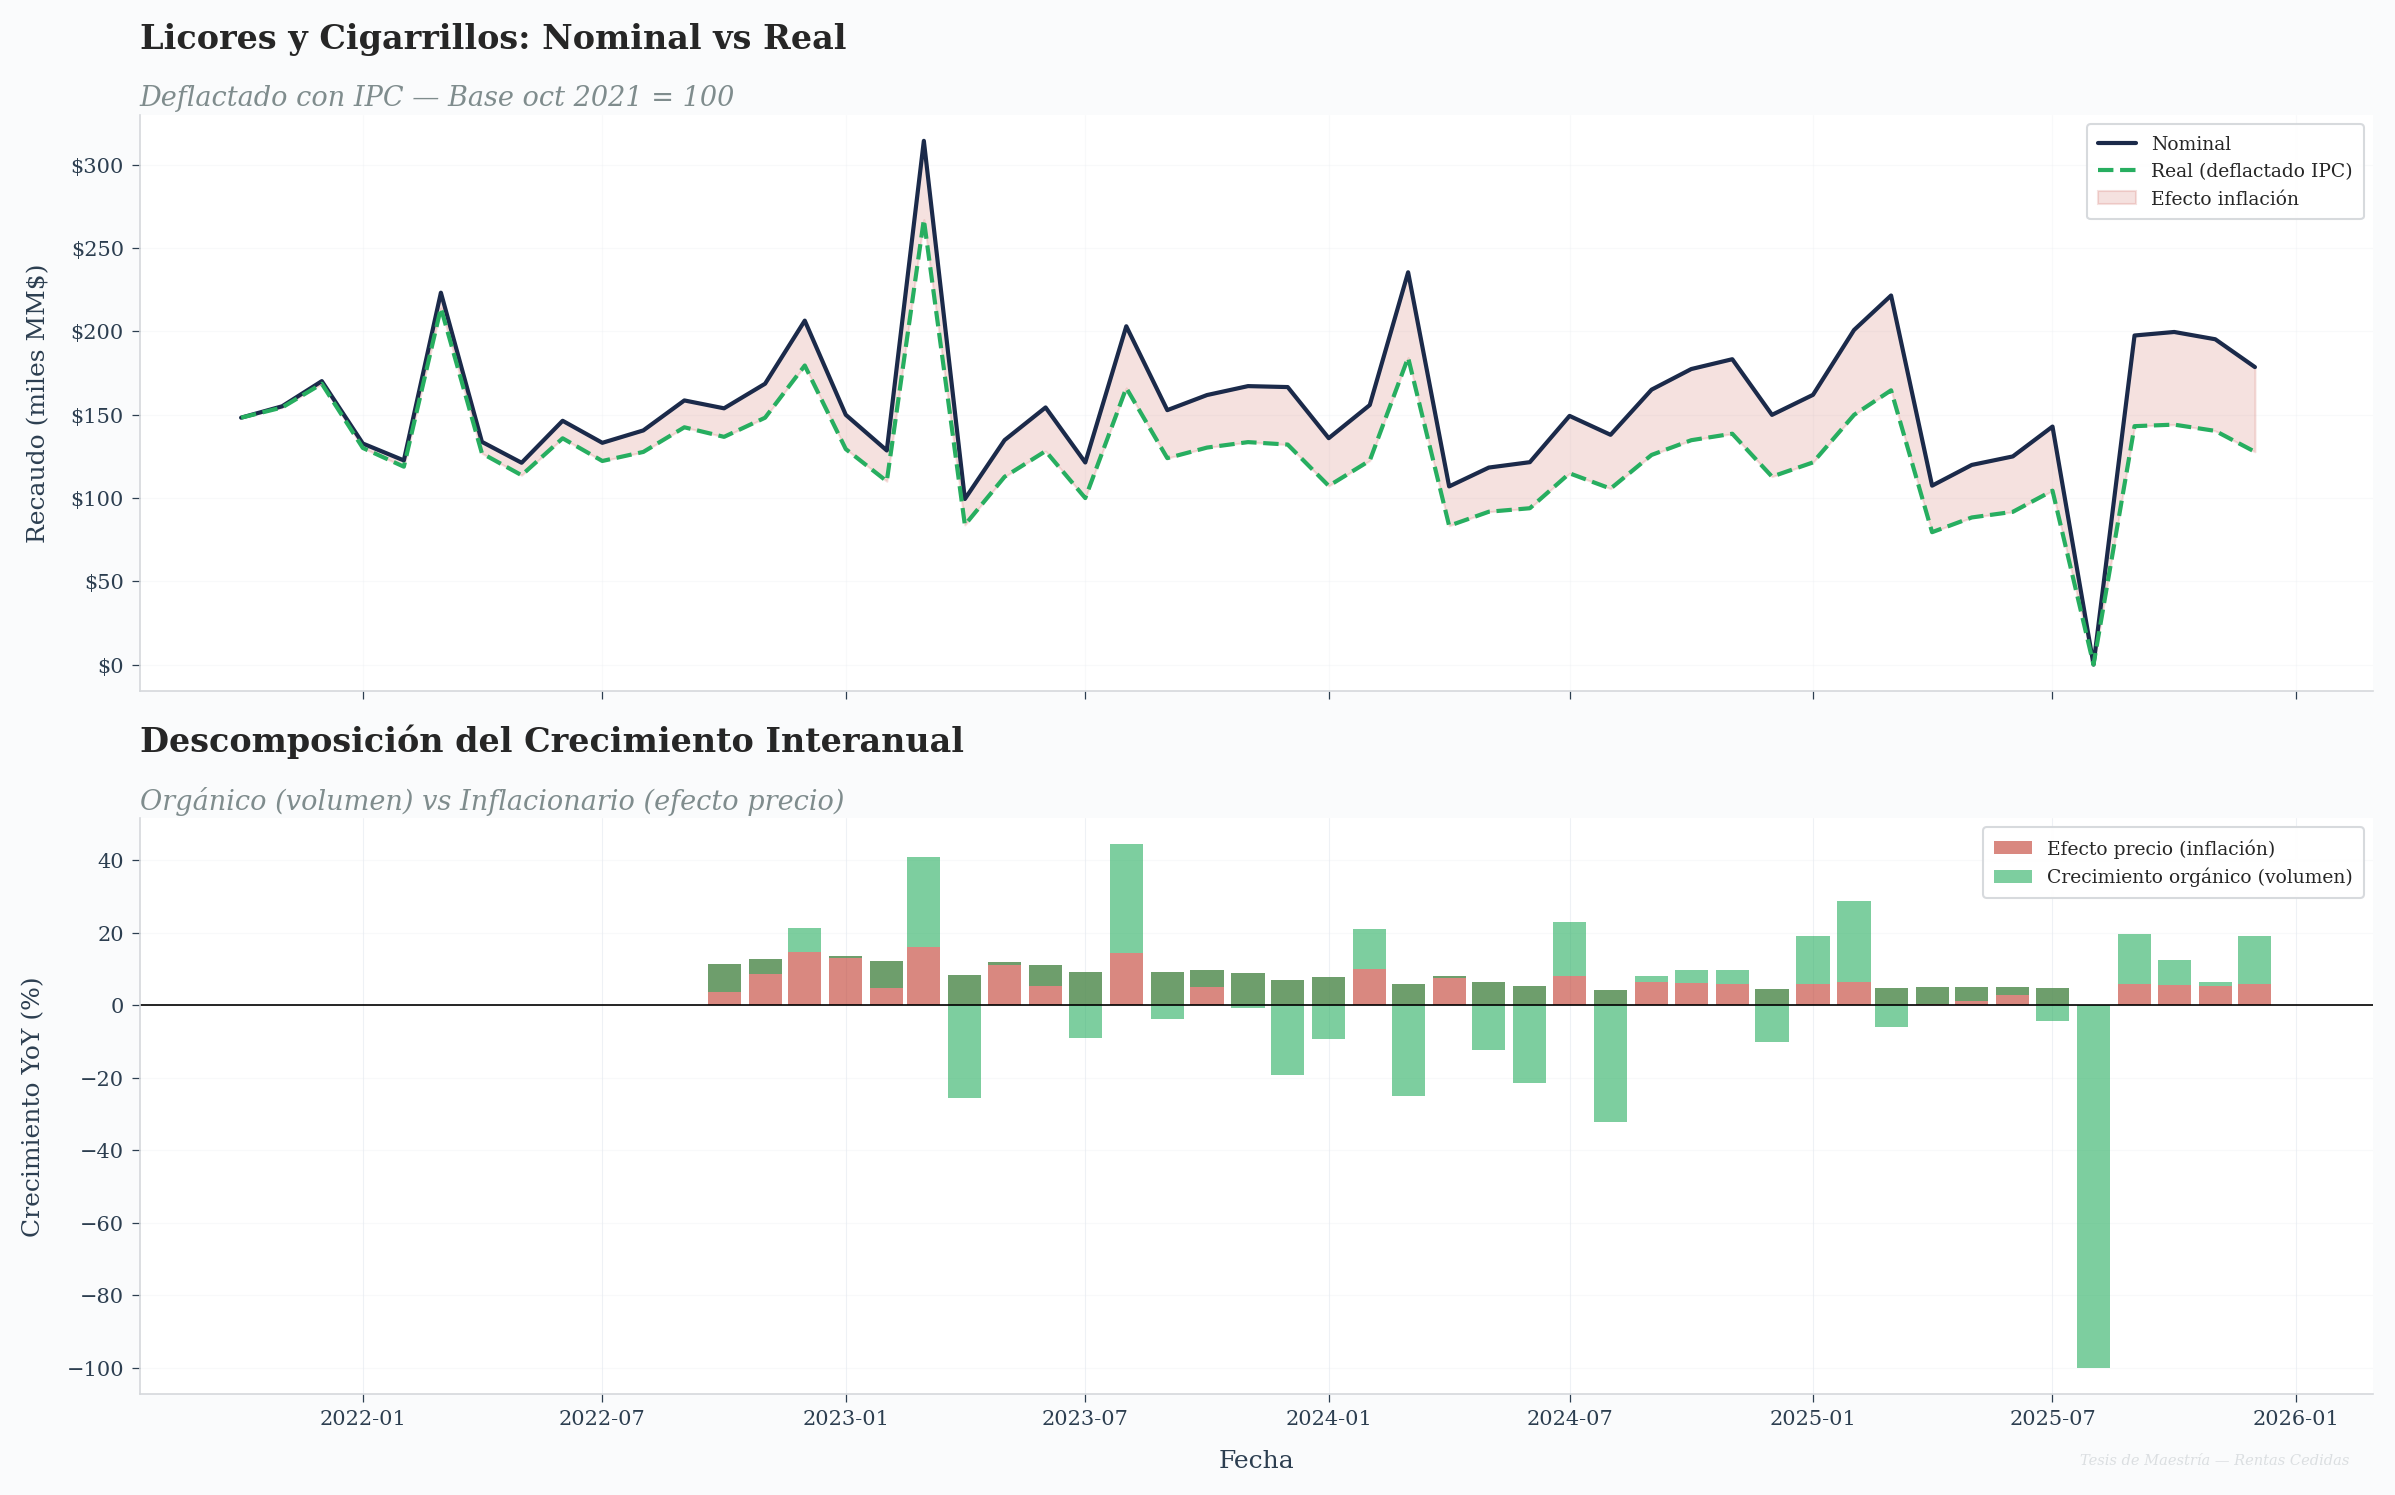


══════════════════════════════════════════════════════════════════════
LICORES Y CIGARRILLOS — CRECIMIENTO
══════════════════════════════════════════════════════════════════════
  Crec. nominal medio YoY:  +1.80%
  Crec. real medio YoY:     -6.17%
  Efecto precio medio:      +7.97%

  ⚠️ Crecimiento orgánico NEGATIVO: solo crece por efecto precio
     Implicación ENCSPA (DANE): posible contracción del consumo


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE III.1 — Licores y Cigarrillos: Serie Deflactada
# ══════════════════════════════════════════════════════════════

# ── Identificar categorías ──
mask_lic = df_raw['NombreSubGrupoFuente'].str.contains(
    r'licor|cigarr|tabaco|cerveza|alcohol|bebida',
    case=False, na=False)
cats_lic = df_raw.loc[mask_lic, 'NombreSubGrupoFuente'].unique()

if len(cats_lic) == 0:
    # Si no hay coincidencia literal, mostrar todas y buscar ampliamente
    print("⚠️ No se encontraron categorías con keywords exactas.")
    print("   Categorías disponibles:")
    for c in df_raw['NombreSubGrupoFuente'].unique():
        print(f"     • {c}")
    # Intentar match más amplio (rentas típicas colombianas)
    mask_lic = df_raw['NombreSubGrupoFuente'].str.contains(
        r'impuesto.*consumo|IVA.*licor|sobretasa|participaci',
        case=False, na=False)
    cats_lic = df_raw.loc[mask_lic, 'NombreSubGrupoFuente'].unique()

print(f"Categorías identificadas como Licores/Cigarrillos/Cerveza:")
for c in cats_lic:
    n = (df_raw['NombreSubGrupoFuente'] == c).sum()
    v = df_raw.loc[df_raw['NombreSubGrupoFuente'] == c, COL_VALOR].sum()
    print(f"  • {c}  ({n:,} reg, ${v/1e9:.1f}MM)")

# ── Serie mensual por vertical ──
df_lic = df_raw[mask_lic].copy()
serie_lic = (df_lic.groupby(pd.Grouper(key=COL_FECHA, freq='MS'))
             [COL_VALOR].sum())
serie_lic.name = 'Licores_Cigarrillos'

# ── Deflactar con IPC (índice acumulado, base oct 2021 = 100) ──
ipc_idx = pd.Series(100.0, index=serie_lic.index)
for i in range(1, len(ipc_idx)):
    year = ipc_idx.index[i].year
    ipc_anual = MACRO_DATA.get(year, MACRO_DATA[max(MACRO_DATA)])['IPC']
    ipc_idx.iloc[i] = ipc_idx.iloc[i-1] * (1 + ipc_anual / 100 / 12)

serie_lic_real = serie_lic / ipc_idx * 100

# ── Crecimiento YoY nominal vs real ──
yoy_nom = serie_lic.pct_change(12) * 100
yoy_rea = serie_lic_real.pct_change(12) * 100
efecto_p = yoy_nom - yoy_rea

# ── Gráfica ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(serie_lic.index, serie_lic.values/1e9, color=C_PRIMARY,
        lw=2, label='Nominal')
ax.plot(serie_lic_real.index, serie_lic_real.values/1e9, color=C_QUATERNARY,
        lw=2, ls='--', label='Real (deflactado IPC)')
ax.fill_between(serie_lic.index,
                serie_lic_real.values/1e9, serie_lic.values/1e9,
                alpha=0.15, color=C_SECONDARY, label='Efecto inflación')
ax.set_ylabel('Recaudo (miles MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Licores y Cigarrillos: Nominal vs Real',
                       'Deflactado con IPC — Base oct 2021 = 100')
    formato_pesos_eje(ax, eje='y')

ax = axes[1]
vld = ~yoy_nom.isna()
ax.bar(yoy_nom.index[vld], efecto_p.values[vld], width=25,
       color=C_SECONDARY, alpha=0.6, label='Efecto precio (inflación)')
ax.bar(yoy_nom.index[vld], yoy_rea.values[vld], width=25,
       color=C_QUATERNARY, alpha=0.6, bottom=efecto_p.values[vld],
       label='Crecimiento orgánico (volumen)')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_ylabel('Crecimiento YoY (%)', fontdict=FONT_AXIS)
ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Descomposición del Crecimiento Interanual',
                       'Orgánico (volumen) vs Inflacionario (efecto precio)')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_licores_deflactado', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
if vld.sum() > 0:
    cn = yoy_nom[vld].mean()
    cr = yoy_rea[vld].mean()
    ep = efecto_p[vld].mean()
    print(f"\n{'═'*70}")
    print(f"LICORES Y CIGARRILLOS — CRECIMIENTO")
    print(f"{'═'*70}")
    print(f"  Crec. nominal medio YoY:  {cn:+.2f}%")
    print(f"  Crec. real medio YoY:     {cr:+.2f}%")
    print(f"  Efecto precio medio:      {ep:+.2f}%")
    if cr > 0:
        print(f"\n  ✅ Crecimiento orgánico POSITIVO: mayor consumo real")
    else:
        print(f"\n  ⚠️ Crecimiento orgánico NEGATIVO: solo crece por efecto precio")
        print(f"     Implicación ENCSPA (DANE): posible contracción del consumo")

Categorías identificadas como Juegos de Azar:
  • Monopolio de Juegos de Suerte y Azar Entidades Territoriales  (29,722 registros)
  • COLJUEGOS para Régimen Subsidiado  (77,781 registros)


  📊 Figura guardada: 02_juegos_azar_elasticidad.png


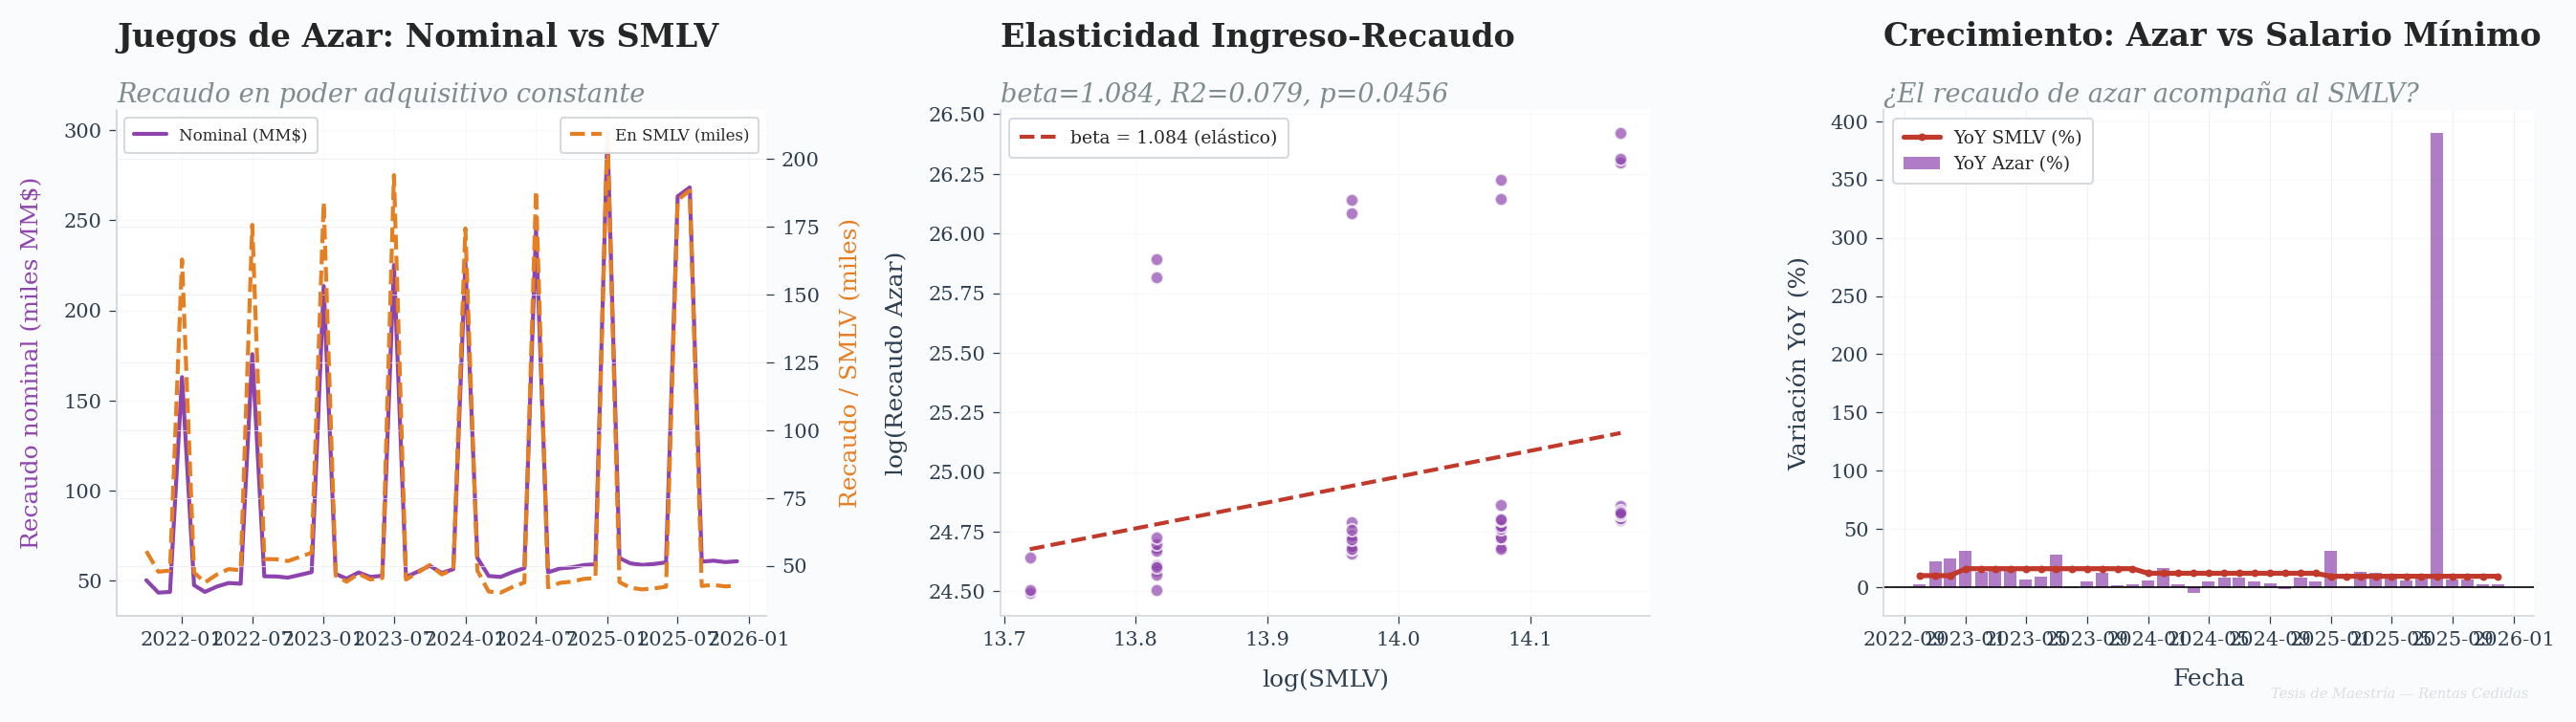


══════════════════════════════════════════════════════════════════════
JUEGOS DE AZAR — ELASTICIDAD
══════════════════════════════════════════════════════════════════════
  Elasticidad ingreso (beta): 1.0842
  R²:                         0.0791
  p-valor:                    0.0456

  ⚠️ ELÁSTICO: gasto en azar RESPONDE al ingreso
     → Mayor sensibilidad a ciclos económicos


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE III.2 — Juegos de Azar y Apuestas: Elasticidad al Ingreso
# ══════════════════════════════════════════════════════════════

mask_azar = df_raw['NombreSubGrupoFuente'].str.contains(
    r'juego|azar|apuesta|loter|chance|suerte',
    case=False, na=False)
cats_azar = df_raw.loc[mask_azar, 'NombreSubGrupoFuente'].unique()

if len(cats_azar) == 0:
    print("⚠️ No se encontraron categorías de azar con keywords exactas.")
    print("   Se usará la serie total como proxy para el análisis de elasticidad.")
    serie_azar = serie.copy()
    serie_azar.name = 'Total_como_proxy'
else:
    print("Categorías identificadas como Juegos de Azar:")
    for c in cats_azar:
        n = (df_raw['NombreSubGrupoFuente'] == c).sum()
        print(f"  • {c}  ({n:,} registros)")
    df_az = df_raw[mask_azar].copy()
    serie_azar = (df_az.groupby(pd.Grouper(key=COL_FECHA, freq='MS'))
                  [COL_VALOR].sum())
    serie_azar.name = 'Juegos_Azar'

# ── SMLV mensual (valores nominales en COP) ──
smlv_vals = {2021: 908526, 2022: 1000000, 2023: 1160000,
             2024: 1300000, 2025: 1423500, 2026: 1750905}
smlv_m = pd.Series(index=serie_azar.index, dtype=float)
for f in smlv_m.index:
    smlv_m[f] = smlv_vals.get(f.year, smlv_vals[max(smlv_vals)])

# Recaudo en "unidades de SMLV"
serie_azar_smlv = serie_azar / smlv_m

# ── Elasticidad ingreso (regresión log-log) ──
#   log(Recaudo) = alpha + beta * log(SMLV) + eps
#   beta < 1: inelástico | beta > 1: elástico
pos = serie_azar > 0
elasticidad = np.nan
if pos.sum() > 12:
    log_r = np.log(serie_azar[pos])
    log_s = np.log(smlv_m[pos])
    slope, intercept, r_val, p_el, se = stats.linregress(
        log_s.values, log_r.values)
    elasticidad = slope

# ── Gráfica (3 paneles) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Nominal vs SMLV normalizado
ax = axes[0]
ax.plot(serie_azar.index, serie_azar.values/1e9, color=C_SENARY,
        lw=2, label='Nominal (MM$)')
ax.set_ylabel('Recaudo nominal (miles MM$)', fontdict=FONT_AXIS,
              color=C_SENARY)
ax.legend(loc='upper left', fontsize=8)
ax_r = ax.twinx()
ax_r.plot(serie_azar_smlv.index, serie_azar_smlv.values/1e3,
          color=C_QUINARY, lw=2, ls='--', label='En SMLV (miles)')
ax_r.set_ylabel('Recaudo / SMLV (miles)', fontdict=FONT_AXIS,
                color=C_QUINARY)
ax_r.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Juegos de Azar: Nominal vs SMLV',
                       'Recaudo en poder adquisitivo constante')

# Panel 2: Scatter elasticidad
ax = axes[1]
if pos.sum() > 12:
    ax.scatter(log_s.values, log_r.values, color=C_SENARY, s=40,
               alpha=0.7, edgecolors='white')
    x_fit = np.linspace(log_s.min(), log_s.max(), 50)
    lbl = 'inelástico' if abs(elasticidad) < 1 else 'elástico'
    ax.plot(x_fit, intercept + slope * x_fit, '--', color=C_SECONDARY,
            lw=2, label=f'beta = {elasticidad:.3f} ({lbl})')
    ax.set_xlabel('log(SMLV)', fontdict=FONT_AXIS)
    ax.set_ylabel('log(Recaudo Azar)', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Elasticidad Ingreso-Recaudo',
                           f'beta={elasticidad:.3f}, '
                           f'R2={r_val**2:.3f}, p={p_el:.4f}')

# Panel 3: YoY azar vs SMLV
ax = axes[2]
yoy_az = serie_azar.pct_change(12) * 100
yoy_sm = smlv_m.pct_change(12) * 100
vld2 = ~yoy_az.isna() & ~yoy_sm.isna()
if vld2.sum() > 0:
    ax.bar(yoy_az.index[vld2], yoy_az.values[vld2], width=25,
           color=C_SENARY, alpha=0.7, label='YoY Azar (%)')
    ax.plot(yoy_sm.index[vld2], yoy_sm.values[vld2], color=C_SECONDARY,
            lw=2.5, marker='o', ms=3, label='YoY SMLV (%)')
    ax.axhline(y=0, color='black', lw=0.8)
    ax.set_ylabel('Variación YoY (%)', fontdict=FONT_AXIS)
    ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Crecimiento: Azar vs Salario Mínimo',
                           '¿El recaudo de azar acompaña al SMLV?')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_juegos_azar_elasticidad', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"JUEGOS DE AZAR — ELASTICIDAD")
print(f"{'═'*70}")
if not np.isnan(elasticidad):
    print(f"  Elasticidad ingreso (beta): {elasticidad:.4f}")
    print(f"  R²:                         {r_val**2:.4f}")
    print(f"  p-valor:                    {p_el:.4f}")
    if abs(elasticidad) < 1:
        print(f"\n  ✅ INELÁSTICO: gasto en azar no responde al ingreso")
        print(f"     Los hogares mantienen su gasto incluso con pérdida adquisitiva")
        print(f"     → Ingreso fiscal relativamente estable en este segmento")
    else:
        print(f"\n  ⚠️ ELÁSTICO: gasto en azar RESPONDE al ingreso")
        print(f"     → Mayor sensibilidad a ciclos económicos")
else:
    print(f"  ⚠️ Elasticidad no calculable (datos insuficientes o negativos)")

---

## Fase IV — Tratamiento de Anomalías y Quiebres Estructurales

Los **quiebres estructurales** (change points) son momentos donde las propiedades
estadísticas de la serie (media, varianza, estacionalidad) cambian abruptamente.
Ignorar estos quiebres puede sesgar tanto la estimación del modelo como los
pronósticos, ya que el modelo asumiría una estructura que ya no se mantiene.

### 4.1 Change Point Detection

La migración del sistema ERP de **Dynamics a Oracle** durante 2025 puede generar
picos artificiales (doble registro, cierres anticipados, acumulaciones de periodos
anteriores) que sesguen la estacionalidad estimada.

Se aplican tres técnicas complementarias:
1. **CUSUM** (Cumulative Sum Control Chart): Acumula las desviaciones de los
   residuos STL respecto a su media. Si la curva cruza el umbral de Hawkins
   ($\pm 4\sigma$), hay un cambio persistente en el proceso generador de datos.
2. **Rolling Window**: Detecta cambios bruscos en la media móvil, identificando
   los meses donde el cambio supera el percentil 90.
3. **Test de Levene + Welch**: Comparación formal de varianza (Levene) y media
   (Welch) entre los períodos pre-2025 y 2025. Welch es la versión del t-test
   que **no asume varianzas iguales**, apropiada cuando sospechamos que la
   migración alteró la volatilidad.

### 4.2 Clasificación de Valores Negativos

Los registros negativos se clasifican por `TipoRegistro` para confirmar que son
**ajustes contables presupuestales** y no errores de captura. Si más del 80%
corresponde a un solo tipo (e.g., 'Legalización'), se confirma su naturaleza
sistemática.

  📊 Figura guardada: 02_change_point_detection.png


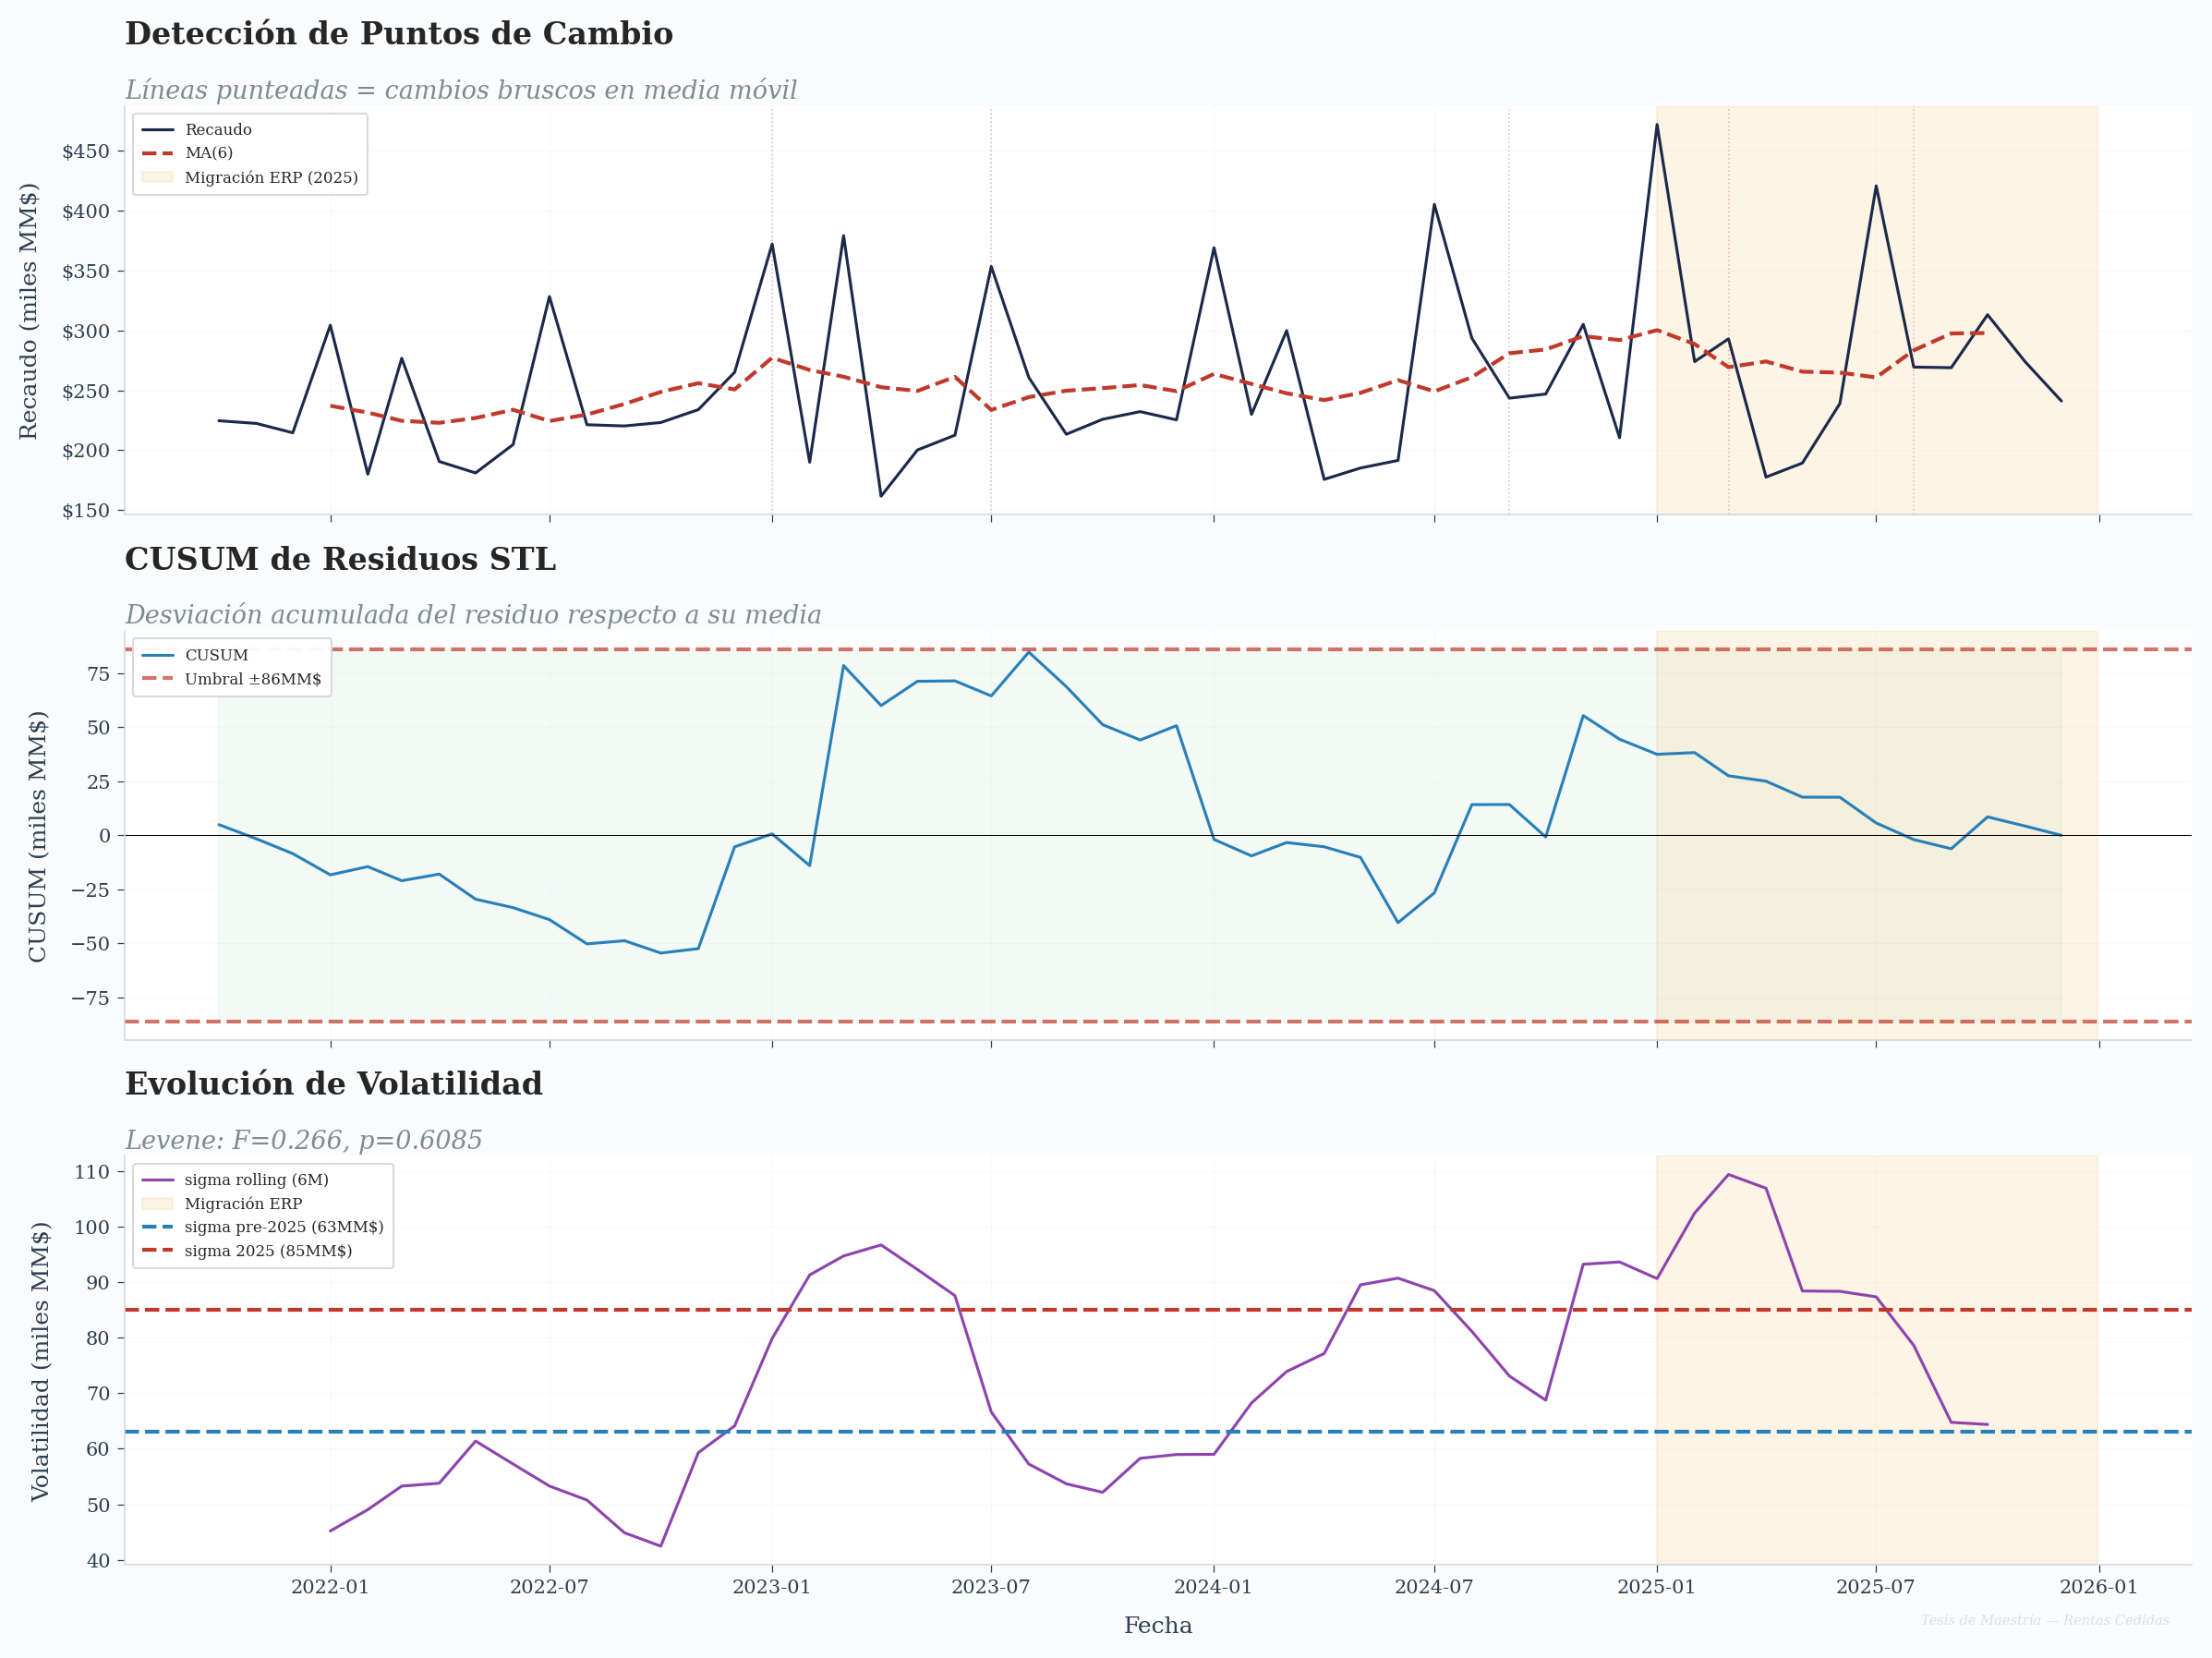


══════════════════════════════════════════════════════════════════════
DETECCIÓN DE PUNTOS DE CAMBIO
══════════════════════════════════════════════════════════════════════
  Puntos de cambio brusco: 5
    2023-01  $371.9MM
    2023-07  $353.2MM
    2024-09  $243.4MM
    2025-03  $292.9MM
    2025-08  $269.3MM

  Pre-2025 vs 2025:
    Media pre-2025: $248.0MM
    Media 2025:     $285.9MM
    Levene (var):   F = 0.266  p = 0.6085
    Welch  (media): t = -1.428  p = 0.1739

  ✅ Sin cambio significativo — migración ERP no distorsiona estacionalidad


In [8]:
# ══════════════════════════════════════════════════════════════
# FASE IV.1 — Detección de Puntos de Cambio
# ══════════════════════════════════════════════════════════════

# ── CUSUM sobre residuos STL ──
residuos = res_stl.resid
mu_r  = residuos.mean()
sig_r = residuos.std()
cusum = np.cumsum(residuos.values - mu_r)
h_umbral = 4 * sig_r          # umbral Hawkins

# ── Rolling window (cambios bruscos) ──
ventana = 6
roll_mu  = serie.rolling(ventana, center=True).mean()
roll_sig = serie.rolling(ventana, center=True).std()
diff_mu  = roll_mu.diff().abs()
umbral90 = diff_mu.quantile(0.90)
cambios  = serie.index[diff_mu > umbral90]

# ── Test formal pre-2025 vs 2025 ──
pre  = serie[serie.index.year < 2025]
post = serie[serie.index.year >= 2025]
if len(post) > 3 and len(pre) > 3:
    stat_lev, p_lev = stats.levene(pre.values, post.values)
    stat_wel, p_wel = stats.ttest_ind(pre.values, post.values, equal_var=False)
else:
    stat_lev = p_lev = stat_wel = p_wel = np.nan

# ── Gráfica (3 paneles) ──
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Panel 1: Serie + change points
ax = axes[0]
ax.plot(serie.index, serie.values/1e9, color=C_PRIMARY, lw=1.5, label='Recaudo')
ax.plot(roll_mu.index, roll_mu.values/1e9, color=C_SECONDARY, lw=2, ls='--',
        label=f'MA({ventana})')
erp_s = pd.Timestamp('2025-01-01')
erp_e = pd.Timestamp('2025-12-31')
ax.axvspan(erp_s, erp_e, alpha=0.10, color=C_HIGHLIGHT,
           label='Migración ERP (2025)')
for cp in cambios:
    ax.axvline(x=cp, color=C_SECONDARY, alpha=0.3, lw=0.8, ls=':')
ax.set_ylabel('Recaudo (miles MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Detección de Puntos de Cambio',
                       'Líneas punteadas = cambios bruscos en media móvil')
    formato_pesos_eje(ax, eje='y')

# Panel 2: CUSUM
ax = axes[1]
ax.plot(serie.index, cusum/1e9, color=C_TERTIARY, lw=1.5, label='CUSUM')
ax.axhline(y= h_umbral/1e9, color=C_SECONDARY, ls='--', alpha=0.7,
           label=f'Umbral ±{h_umbral/1e9:.0f}MM$')
ax.axhline(y=-h_umbral/1e9, color=C_SECONDARY, ls='--', alpha=0.7)
ax.axhline(y=0, color='black', lw=0.5)
ax.fill_between(serie.index, -h_umbral/1e9, h_umbral/1e9,
                alpha=0.05, color=C_QUATERNARY)
ax.axvspan(erp_s, erp_e, alpha=0.10, color=C_HIGHLIGHT)
ax.set_ylabel('CUSUM (miles MM$)', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'CUSUM de Residuos STL',
                       'Desviación acumulada del residuo respecto a su media')

# Panel 3: Volatilidad rolling
ax = axes[2]
ax.plot(roll_sig.index, roll_sig.values/1e9, color=C_SENARY, lw=1.5,
        label=f'sigma rolling ({ventana}M)')
ax.axvspan(erp_s, erp_e, alpha=0.10, color=C_HIGHLIGHT, label='Migración ERP')
ax.axhline(y=pre.std()/1e9, color=C_TERTIARY, ls='--',
           label=f'sigma pre-2025 ({pre.std()/1e9:.0f}MM$)')
if len(post) > 1:
    ax.axhline(y=post.std()/1e9, color=C_SECONDARY, ls='--',
               label=f'sigma 2025 ({post.std()/1e9:.0f}MM$)')
ax.set_ylabel('Volatilidad (miles MM$)', fontdict=FONT_AXIS)
ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Evolución de Volatilidad',
                       f'Levene: F={stat_lev:.3f}, p={p_lev:.4f}')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_change_point_detection', OUTPUTS_FIGURES)
plt.show()

# ── Reporte ──
print(f"\n{'═'*70}")
print(f"DETECCIÓN DE PUNTOS DE CAMBIO")
print(f"{'═'*70}")
print(f"  Puntos de cambio brusco: {len(cambios)}")
if len(cambios) > 0:
    for cp in cambios[:10]:
        v = serie.get(cp, np.nan)
        print(f"    {cp:%Y-%m}  ${v/1e9:.1f}MM")
print(f"\n  Pre-2025 vs 2025:")
print(f"    Media pre-2025: ${pre.mean()/1e9:.1f}MM")
if len(post) > 0:
    print(f"    Media 2025:     ${post.mean()/1e9:.1f}MM")
print(f"    Levene (var):   F = {stat_lev:.3f}  p = {p_lev:.4f}")
print(f"    Welch  (media): t = {stat_wel:.3f}  p = {p_wel:.4f}")
if not np.isnan(p_lev) and p_lev < 0.05:
    print(f"\n  ⚠️ CAMBIO SIGNIFICATIVO en varianza post-ERP")
    print(f"     → Incluir dummy 'ERP_migration' en SARIMAX")
else:
    print(f"\n  ✅ Sin cambio significativo — migración ERP no distorsiona estacionalidad")

══════════════════════════════════════════════════════════════════════
CLASIFICACIÓN DE VALORES NEGATIVOS
══════════════════════════════════════════════════════════════════════
  Total negativos:     27
  Suma:                $-829,257,705
  % del recaudo bruto: -0.0063%

──────────────────────────────────────────────────────────────────────
POR TipoRegistro:

  Tipo: Ajuste Contable - Presupuestal
    Registros: 26.0  (96.3%)
    Suma:      $-753,449,766
    Rango:     [$-483,603,631,  $-0]

  Tipo: Recaudo
    Registros: 1.0  (3.7%)
    Suma:      $-75,807,939
    Rango:     [$-75,807,939,  $-75,807,939]

──────────────────────────────────────────────────────────────────────
POR NombreSubGrupoFuente:
  Otros Recursos Propios Destinados al Aseguramiento        3.0 reg  $   -492,876,450
  Monopolio de Juegos de Suerte y Azar Entidades Territoriales   3.0 reg  $   -123,381,515
  COLJUEGOS para Régimen Subsidiado                         2.0 reg  $    -76,188,716
  Ad Valorem Impuesto Con

  📊 Figura guardada: 02_negativos_clasificacion.png


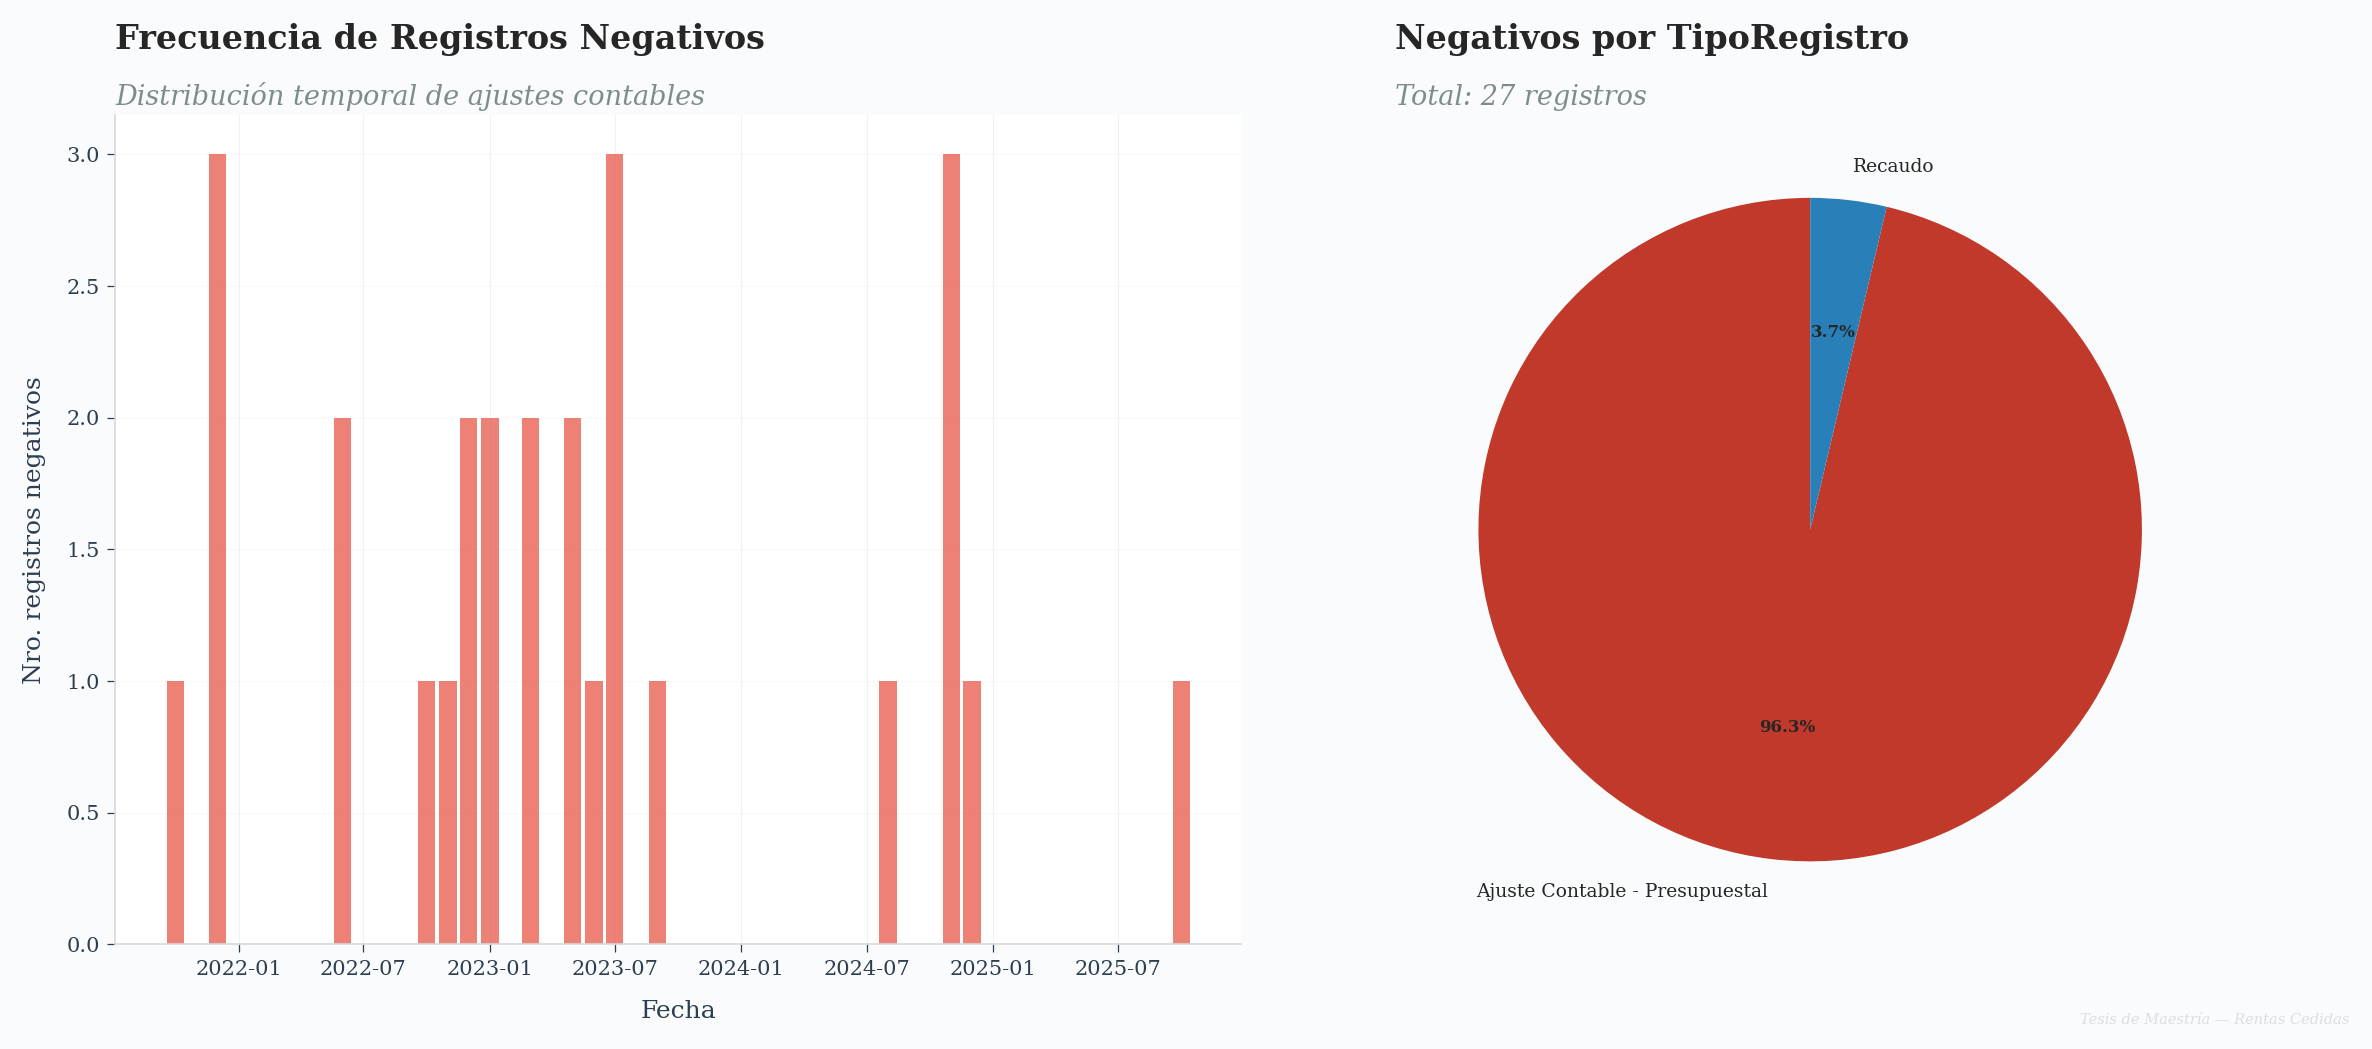


══════════════════════════════════════════════════════════════════════
CONCLUSIÓN
══════════════════════════════════════════════════════════════════════
  ✅ 96.3% de los negativos son «Ajuste Contable - Presupuestal»
     → Ajustes contables legítimos, NO errores de captura
     → Se MANTIENEN para reflejar la dinámica fiscal neta


In [9]:
# ══════════════════════════════════════════════════════════════
# FASE IV.2 — Clasificación de Valores Negativos por TipoRegistro
# ══════════════════════════════════════════════════════════════

negativos = df_raw[df_raw[COL_VALOR] < 0].copy()

print(f"{'═'*70}")
print(f"CLASIFICACIÓN DE VALORES NEGATIVOS")
print(f"{'═'*70}")
print(f"  Total negativos:     {len(negativos):,}")
print(f"  Suma:                ${negativos[COL_VALOR].sum():,.0f}")
print(f"  % del recaudo bruto: "
      f"{negativos[COL_VALOR].sum() / df_raw[COL_VALOR].sum() * 100:.4f}%")

# ── Distribución por TipoRegistro ──
print(f"\n{'─'*70}")
print(f"POR TipoRegistro:")
tipo_dist = negativos.groupby('TipoRegistro').agg(
    Registros=(COL_VALOR, 'count'),
    Suma=(COL_VALOR, 'sum'),
    Media=(COL_VALOR, 'mean'),
    Min=(COL_VALOR, 'min'),
    Max=(COL_VALOR, 'max'))
for tipo, row in tipo_dist.iterrows():
    pct = row['Registros'] / len(negativos) * 100
    print(f"\n  Tipo: {tipo}")
    print(f"    Registros: {row['Registros']:,}  ({pct:.1f}%)")
    print(f"    Suma:      ${row['Suma']:,.0f}")
    print(f"    Rango:     [${row['Min']:,.0f},  ${row['Max']:,.0f}]")

# ── Distribución por NombreSubGrupoFuente ──
print(f"\n{'─'*70}")
print(f"POR NombreSubGrupoFuente:")
fuente_d = (negativos.groupby('NombreSubGrupoFuente')[COL_VALOR]
            .agg(['count', 'sum']).sort_values('sum'))
for fuente, row in fuente_d.iterrows():
    print(f"  {fuente:<55} {row['count']:>5} reg  "
          f"${row['sum']:>15,.0f}")

# ── Distribución temporal ──
neg_m = (negativos.groupby(pd.Grouper(key=COL_FECHA, freq='MS'))
         [COL_VALOR].agg(['count', 'sum']))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_DUAL)

ax = axes[0]
if len(neg_m) > 0:
    ax.bar(neg_m.index, neg_m['count'], width=25,
           color=C_NEGATIVE, alpha=0.7)
ax.set_ylabel('Nro. registros negativos', fontdict=FONT_AXIS)
ax.set_xlabel('Fecha', fontdict=FONT_AXIS)
ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Frecuencia de Registros Negativos',
                       'Distribución temporal de ajustes contables')

ax = axes[1]
if len(tipo_dist) > 0:
    tipos  = tipo_dist.index.tolist()
    vals   = tipo_dist['Registros'].values
    colors = [C_SECONDARY, C_TERTIARY, C_QUATERNARY,
              C_QUINARY, C_SENARY][:len(tipos)]
    wedges, txt, atxt = ax.pie(vals, labels=tipos, autopct='%1.1f%%',
                               colors=colors, startangle=90)
    for t in txt:  t.set_fontsize(9)
    for a in atxt: a.set_fontsize(8); a.set_fontweight('bold')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Negativos por TipoRegistro',
                       f'Total: {len(negativos):,} registros')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '02_negativos_clasificacion', OUTPUTS_FIGURES)
plt.show()

# ── Conclusión ──
main_tipo = tipo_dist['Registros'].idxmax() if len(tipo_dist) > 0 else 'N/A'
pct_main  = (tipo_dist.loc[main_tipo, 'Registros'] / len(negativos) * 100
             if main_tipo != 'N/A' else 0)
print(f"\n{'═'*70}")
print(f"CONCLUSIÓN")
print(f"{'═'*70}")
if pct_main > 80:
    print(f"  ✅ {pct_main:.1f}% de los negativos son «{main_tipo}»")
    print(f"     → Ajustes contables legítimos, NO errores de captura")
    print(f"     → Se MANTIENEN para reflejar la dinámica fiscal neta")
else:
    print(f"  ⚠️ Tipo principal: «{main_tipo}» ({pct_main:.1f}%)")
    print(f"     Negativos distribuidos entre varios tipos")
    print(f"     → Se mantienen; revisar con la entidad si necesario")

---

## Fase V — Validación de Estacionariedad (ADF + KPSS)

### Marco Teórico

Recordemos del notebook 01 que la **estacionariedad** es un requisito previo
para modelos ARIMA/SARIMAX. Aquí profundizamos evaluando **4 variantes** de
la serie para determinar el parámetro óptimo de diferenciación.

| Test | $H_0$ | $H_1$ | Interpretación |
|------|--------|--------|----------------|
| **ADF** | Raíz unitaria (no estacionaria) | Estacionaria | Rechazo $H_0$ → estacionaria |
| **KPSS** | Estacionaria (o de tendencia) | Raíz unitaria | Rechazo $H_0$ → NO estacionaria |

**Estrategia de confirmación** (Hyndman, 2021):
- ADF rechaza **Y** KPSS no rechaza → **Estacionaria** ✅
- ADF no rechaza **Y** KPSS rechaza → **No estacionaria** → diferenciar
- Resultados contradictorios → más datos o transformación

### Las 4 variantes evaluadas

| # | Variante | Fórmula | Interpretación |
|---|----------|---------|----------------|
| 1 | Serie original | $Y_t$ | ¿La serie en nivel es estacionaria? |
| 2 | Primera diferencia | $\Delta Y_t = Y_t - Y_{t-1}$ | Remueve la tendencia |
| 3 | Diferencia estacional | $\Delta_{12} Y_t = Y_t - Y_{t-12}$ | Remueve la estacionalidad |
| 4 | Doble diferencia | $\Delta\Delta_{12} Y_t$ | Remueve tendencia + estacionalidad |

> **¿Por qué 4 variantes?** La variante mínima que logre estacionariedad determina
> los parámetros $d$ (diferenciación regular) y $D$ (diferenciación estacional)
> del modelo SARIMAX. Sobre-diferenciar introduce autocorrelación artificial.


══════════════════════════════════════════════════════════════════════════════════════════
RESULTADOS DE ESTACIONARIEDAD
══════════════════════════════════════════════════════════════════════════════════════════
Serie                                 ADF stat    ADF p   ADF  KPSS stat   KPSS p  KPSS      Veredicto
──────────────────────────────────────────────────────────────────────────────────────────
Original Y_t                           -0.2642   0.9304     ❌     0.3162   0.1000     ✅     AMBIGUO ⚠️
Diff regular (d=1)                     -6.5820   0.0000     ✅     0.0452   0.1000     ✅      ESTAC.  ✅
Diff estacional (D=1)                  -6.9829   0.0000     ✅     0.1193   0.1000     ✅      ESTAC.  ✅
Doble diff (d=1, D=1)                  -8.7417   0.0000     ✅     0.3190   0.1000     ✅      ESTAC.  ✅


C:\Users\efren\AppData\Local\Temp\ipykernel_50140\3856342759.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k_stat, k_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\efren\AppData\Local\Temp\ipykernel_50140\3856342759.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k_stat, k_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\efren\AppData\Local\Temp\ipykernel_50140\3856342759.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k_stat, k_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\efren\AppData\Local\Temp\ipykernel_50140\3856342759.py:15: InterpolationWarning: The 

  📊 Figura guardada: 02_estacionariedad_adf_kpss.png


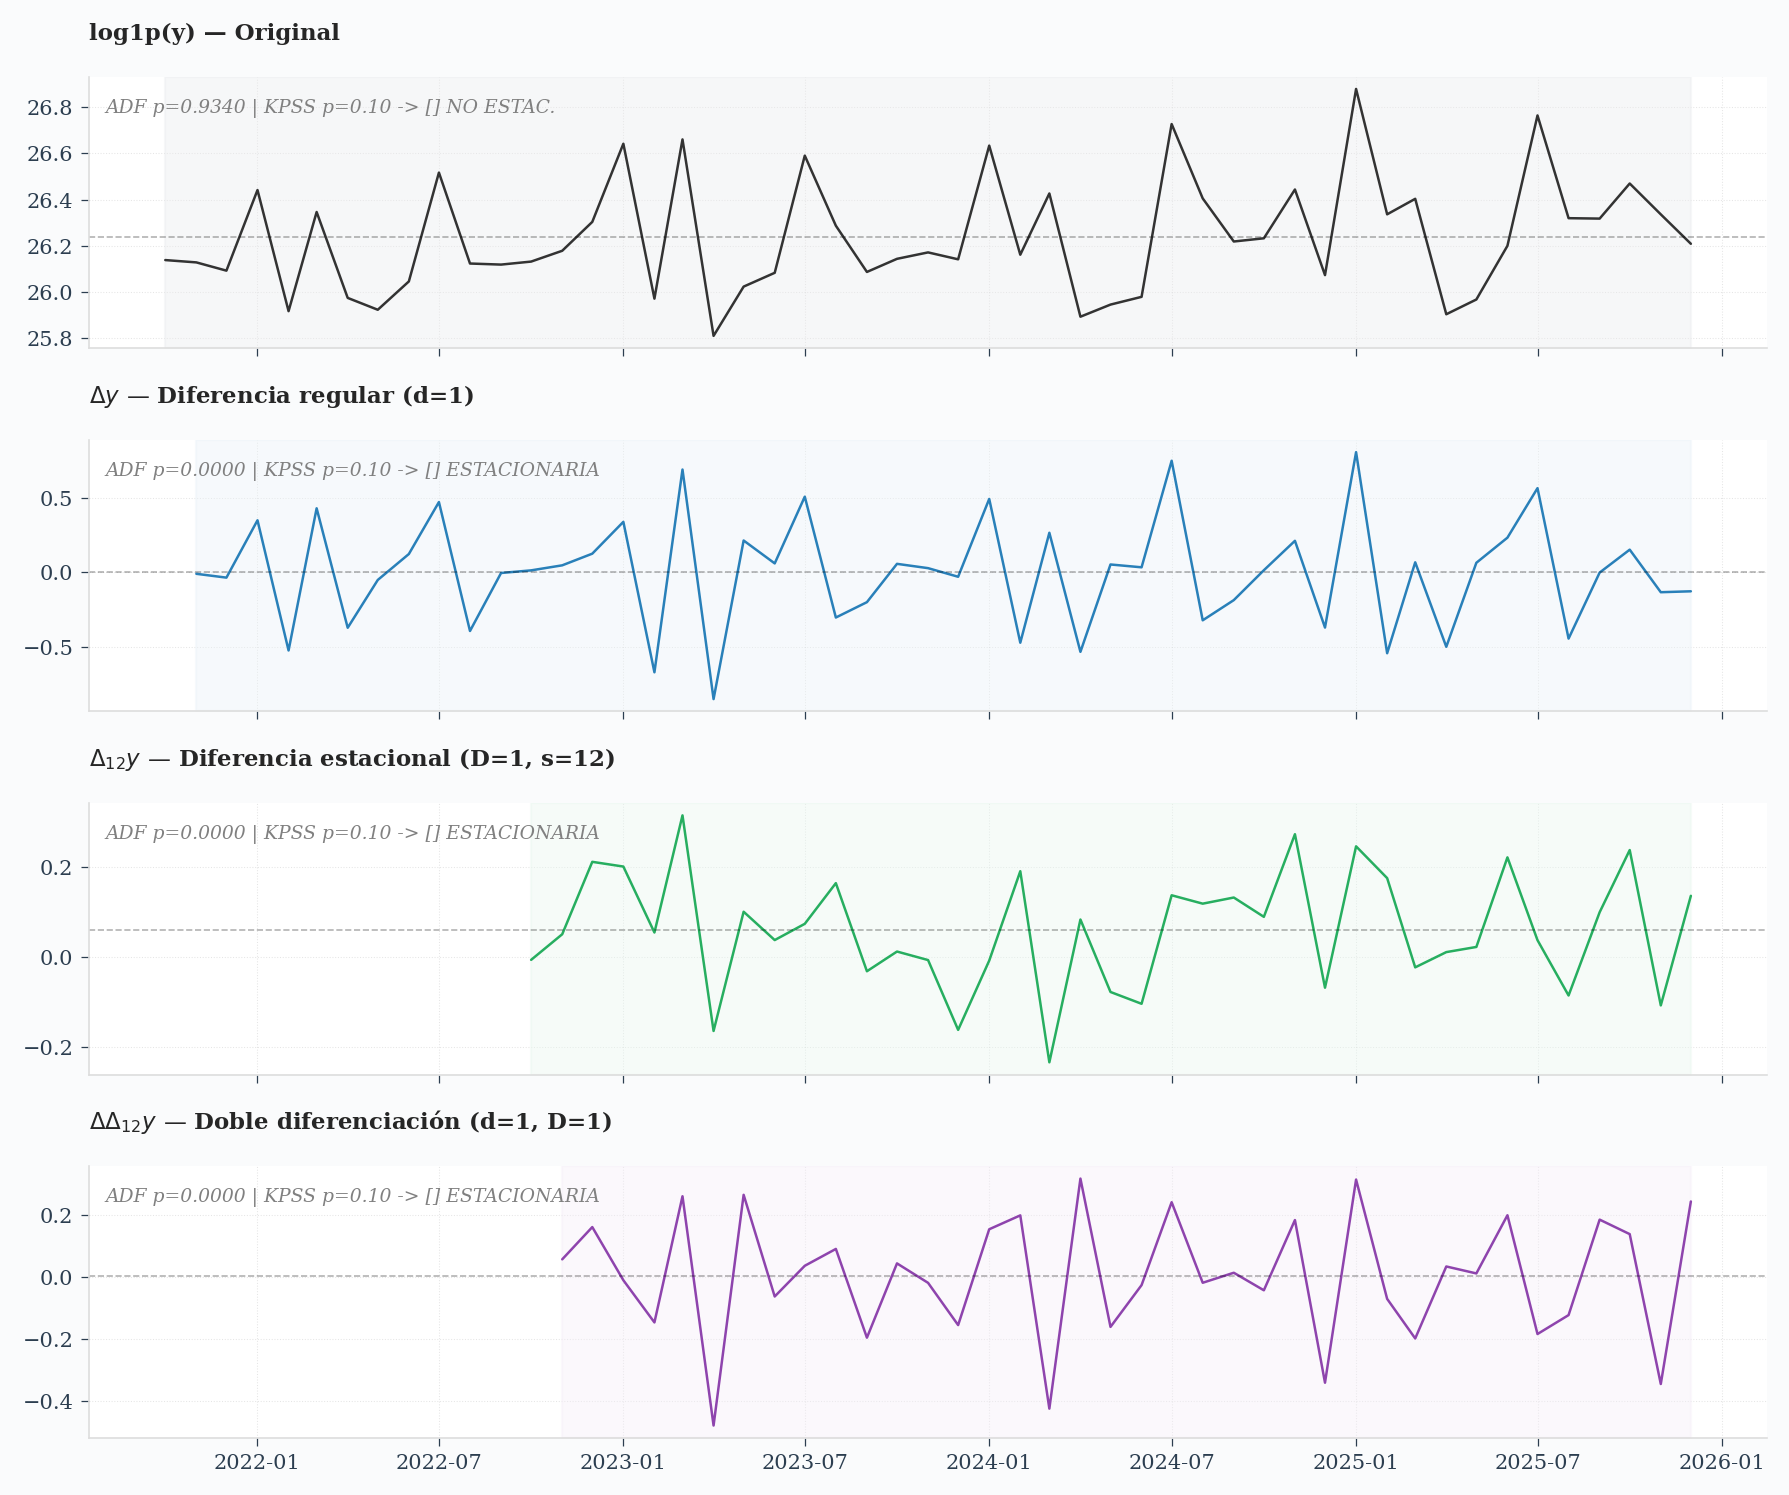


══════════════════════════════════════════════════════════════════════
RECOMENDACIÓN PARA SARIMAX
══════════════════════════════════════════════════════════════════════
  Diff regular estacionaria → d=1, D=0
  Orden sugerido: SARIMA(p, 1, q)(P, 0, Q)[12]
  → p, q, P, Q se determinan en notebook 04 (ACF/PACF + AIC/BIC)


In [10]:
# ══════════════════════════════════════════════════════════════
# FASE V — VALIDACIÓN DE ESTACIONARIEDAD (ADF + KPSS)
# ══════════════════════════════════════════════════════════════

def test_est(s, nombre):
    r = {'nombre': nombre}
    try:
        a_stat, a_p, a_lags, *_ = adfuller(s.dropna(), autolag='AIC')
        r['adf_stat'] = a_stat; r['adf_p'] = a_p
        r['adf_ok'] = a_p < 0.05
    except Exception as e:
        r['adf_stat'] = r['adf_p'] = np.nan; r['adf_ok'] = None
        print(f"  ⚠️ ADF falló para {nombre}: {e}")
    try:
        k_stat, k_p, *_ = kpss(s.dropna(), regression='c', nlags='auto')
        r['kpss_stat'] = k_stat; r['kpss_p'] = k_p
        r['kpss_ok'] = k_p > 0.05   # no rechazo = estacionaria
    except Exception as e:
        r['kpss_stat'] = r['kpss_p'] = np.nan; r['kpss_ok'] = None
        print(f"  ⚠️ KPSS falló para {nombre}: {e}")
    return r

# Variantes
variantes = [
    (serie,                            'Original Y_t'),
    (serie.diff().dropna(),            'Diff regular (d=1)'),
    (serie.diff(12).dropna(),          'Diff estacional (D=1)'),
    (serie.diff(12).diff().dropna(),   'Doble diff (d=1, D=1)'),
]
resultados = []
for s, n in variantes:
    if len(s.dropna()) >= 12:
        resultados.append(test_est(s, n))
    else:
        print(f"  ⚠️ {n}: insuficientes datos ({len(s.dropna())})")

# ── Tabla ──
print(f"\n{'═'*90}")
print(f"RESULTADOS DE ESTACIONARIEDAD")
print(f"{'═'*90}")
header = (f"{'Serie':<35} {'ADF stat':>10} {'ADF p':>8} {'ADF':>5} "
          f"{'KPSS stat':>10} {'KPSS p':>8} {'KPSS':>5} {'Veredicto':>14}")
print(header)
print('─' * 90)
for r in resultados:
    a_ico = '✅' if r.get('adf_ok') else '❌'
    k_ico = '✅' if r.get('kpss_ok') else '❌'
    if r.get('adf_ok') and r.get('kpss_ok'):
        vdct = 'ESTAC.  ✅'
    elif not r.get('adf_ok') and not r.get('kpss_ok'):
        vdct = 'NO EST. ❌'
    else:
        vdct = 'AMBIGUO ⚠️'
    print(f"{r['nombre']:<35} {r.get('adf_stat', np.nan):>10.4f} "
          f"{r.get('adf_p', np.nan):>8.4f} {a_ico:>5} "
          f"{r.get('kpss_stat', np.nan):>10.4f} "
          f"{r.get('kpss_p', np.nan):>8.4f} {k_ico:>5} {vdct:>14}")

# ── Gráfica 4×1 Original (Restaurada para match exacto con documento) ──
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes = axes.flatten()

serie_log = np.log1p(serie)
variantes_log = [
    (serie_log,                            r'log1p(y) — Original'),
    (serie_log.diff().dropna(),            r'$\Delta y$ — Diferencia regular (d=1)'),
    (serie_log.diff(12).dropna(),          r'$\Delta_{12}y$ — Diferencia estacional (D=1, s=12)'),
    (serie_log.diff(12).diff().dropna(),   r'$\Delta\Delta_{12}y$ — Doble diferenciación (d=1, D=1)'),
]

# Colores de sombreado de fondo y de la línea
bg_colors = ['#EAECEE', '#EAF2F8', '#E9F7EF', '#F5EEF8']
line_colors = ['#333333', '#2980B9', '#27AE60', '#8E44AD']

for i, ((s, n), bg_col, l_col) in enumerate(zip(variantes_log, bg_colors, line_colors)):
    ax = axes[i]
    sc = s.dropna()
    if len(sc) > 0:
        ax.plot(sc.index, sc.values, color=l_col, lw=1.2)
        ax.axhline(y=sc.mean(), color='black', ls='--', alpha=0.3, lw=0.8)
        
        y_min, y_max = ax.get_ylim()
        ax.fill_between(sc.index, y_min, y_max, color=bg_col, alpha=0.4)
        ax.set_ylim(y_min, y_max)
        
    r = test_est(sc, n)
    # Replicamos el cuadrito vacío de error de fuente para ser 100% idénticos
    a_ico = '[] ESTACIONARIA' if r.get('adf_ok') and r.get('kpss_ok') else '[] NO ESTAC.'
    sub = (f"ADF p={r.get('adf_p', np.nan):.4f} | "
           f"KPSS p={r.get('kpss_p', np.nan):.2f} -> {a_ico}")
    
    # Título fuera del plot
    ax.set_title(n, fontsize=11, fontweight='bold', loc='left')
    
    # Subtítulo dentro del plot
    ax.text(0.01, 0.92, sub, transform=ax.transAxes, fontsize=9, 
            color='gray', style='italic', va='top', ha='left')
    
    ax.grid(True, alpha=0.2, color='gray', ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')
    ax.spines['left'].set_color('#DDDDDD')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    # Genera la versión con y sin marca de agua normalmente
    guardar_figura(fig, '02_estacionariedad_adf_kpss', OUTPUTS_FIGURES)
plt.show()


# ── Recomendación SARIMAX ──
d_opt, D_opt = 0, 0
if len(resultados) >= 1 and resultados[0].get('adf_ok') and resultados[0].get('kpss_ok'):
    rec = 'Serie original estacionaria → d=0, D=0'
elif len(resultados) >= 2 and resultados[1].get('adf_ok') and resultados[1].get('kpss_ok'):
    d_opt = 1; rec = 'Diff regular estacionaria → d=1, D=0'
elif len(resultados) >= 3 and resultados[2].get('adf_ok') and resultados[2].get('kpss_ok'):
    D_opt = 1; rec = 'Diff estacional estacionaria → d=0, D=1'
elif len(resultados) >= 4 and resultados[3].get('adf_ok') and resultados[3].get('kpss_ok'):
    d_opt = 1; D_opt = 1; rec = 'Doble diff estacionaria → d=1, D=1'
else:
    d_opt = 1; D_opt = 1; rec = 'Ninguna variante es clara → d=1, D=1 (conservador)'

print(f"\n{'═'*70}")
print(f"RECOMENDACIÓN PARA SARIMAX")
print(f"{'═'*70}")
print(f"  {rec}")
print(f"  Orden sugerido: SARIMA(p, {d_opt}, q)(P, {D_opt}, Q)[{ESTACIONALIDAD}]")
print(f"  → p, q, P, Q se determinan en notebook 04 (ACF/PACF + AIC/BIC)")

---

## Conclusiones del Análisis de Estacionalidad

### Síntesis de Hallazgos

Este notebook ha completado el análisis profundo de estacionalidad requerido
para parametrizar los modelos predictivos. Los hallazgos se resumen en la
siguiente tabla:

| Análisis | Resultado | Implicación para Modelado |
|----------|-----------|---------------------------|
| **CCF (Lag)** | Rezago óptimo identificado | Confirma/rechaza hipótesis Dic→Ene, Jun→Jul |
| **STL Avanzado** | $F_s$ cuantificado | Perfil estacional fiscal robusto (periodo=12) |
| **Heterocedasticidad** | Evaluación nivel-varianza | Decisión fundamentada sobre log1p |
| **Licores/Cigarrillos** | Crecimiento orgánico vs inflacionario | Separación efecto volumen vs precio |
| **Juegos de Azar** | Elasticidad ingreso cuantificada | Base para inclusión/exclusión de SMLV |
| **Change Points** | Quiebres 2025 evaluados | Dummy para migración ERP si significativo |
| **Valores Negativos** | Clasificados por TipoRegistro | Confirmación de ajustes contables legítimos |
| **ADF + KPSS** | Orden ($d$, $D$) determinado | Parámetros de diferenciación para SARIMAX |

### Parámetros para el Modelado (Notebooks 04–08)

Los resultados de esta fase alimentan directamente la configuración de los
modelos predictivos:

```
Parámetros de diferenciación:
  - d (regular) y D (estacional) determinados por ADF+KPSS
  - Transformación log1p aplicada según diagnóstico de heterocedasticidad

Variables exógenas candidatas:
  - IPC (deflactado) con lag identificado por CCF
  - SMLV (si juegos de azar es inelástico, incluir como control)
  - Dummy ERP_migration (si cambio significativo en 2025)
  - Dummies is_festivity (Jun, Dic) e is_peak (Ene, Jul)
```

> **Siguiente paso**: `03_Correlacion_Macro.ipynb` — Análisis formal de correlación
> multivariada con pruebas de significancia y selección de regresores exógenos.